# Chapter 6 : Ligand Design

**Source:** *Computational Chemistry* (Oxford Chemistry Primers)

Sections covered: QSAR and 3D-QSAR, inferred receptor sites, receptor mapping and docking, generating new
structures, molecular similarity.

Chapter 5 modelled the target. This chapter turns the problem round and asks what should bind to it and,
when the target's structure is unknown, how much of it can be inferred from the ligands alone.

**A note on run time**. Some cells in this chapter run a search rather than a formula the docking runs of 6.3, the atom-by-atom fitting of 6.4, the shape-similarity optimization of 6.5  and those take tens of seconds each on an unloaded machine. All of it is plain CPU work in numpy and scipy, single-threaded in places, so it runs considerably slower on a laptop that is throttling, on battery, or busy with other applications. Expect a full Restart & Run All to take a few minutes, and expect the printed timings and speed ratios to differ from run to run for the same reason. The scientific results do not: every stochastic step is seeded, so ranks, RMSDs, energies and cluster counts should reproduce exactly.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from itertools import combinations
from scipy.optimize import minimize
from scipy.spatial.transform import Rotation
from sklearn.cross_decomposition import PLSRegression
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut

%matplotlib inline
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.width", 120)

rng = np.random.default_rng(6)

# --- van der Waals radii (Angstrom), enough for the elements used in this chapter
VDW = {"H": 1.20, "C": 1.70, "N": 1.55, "O": 1.52, "S": 1.80}


def kabsch(P, Q):
    """Rotation minimizing RMSD between two centred point sets, P onto Q."""
    C = P.T @ Q
    V, S, Wt = np.linalg.svd(C)
    d = np.sign(np.linalg.det(V @ Wt))
    D = np.diag([1.0, 1.0, d])          # d = -1 forbids a reflection
    return V @ D @ Wt


def superimpose(P, Q):
    """Least-squares fit of P onto Q using paired points. Returns fitted P and RMSD."""
    Pc, Qc = P.mean(0), Q.mean(0)
    R = kabsch(P - Pc, Q - Qc)
    fitted = (P - Pc) @ R + Qc
    return fitted, float(np.sqrt(((fitted - Q) ** 2).sum(1).mean()))


def grid_points(lo, hi, n):
    """Regular cubic lattice, returned as an (n^3, 3) array plus the axis values."""
    ax = np.linspace(lo, hi, n)
    G = np.stack(np.meshgrid(ax, ax, ax, indexing="ij"), axis=-1)
    return G.reshape(-1, 3), ax


def lennard_jones(r, eps, sigma, cap=None):
    """12-6 potential, optionally truncated the way CoMFA truncates its steric field."""
    with np.errstate(over="ignore", divide="ignore"):
        E = 4 * eps * ((sigma / r) ** 12 - (sigma / r) ** 6)
    return np.minimum(E, cap) if cap is not None else E


print(f"numpy {np.__version__}")
print("shared geometry and energy helpers defined")

numpy 2.1.3
shared geometry and energy helpers defined


**What we investigated:** the toolkit for this chapter is different in kind from the previous ones. Chapters 2
to 4 needed an energy function; this chapter needs an *alignment* function, and `kabsch` is the whole basis of
it. Every method in sections 6.1 and 6.2 — 3D-QSAR fields, pharmacophores, receptor volumes — assumes the
molecules have already been superimposed, so the least-squares fit is not a side detail but the step
everything else rests on.

Note: the sign correction inside `kabsch` matters here more than usual. Without the `d = -1` guard the
singular value decomposition will happily return a reflection when that fits better, which for molecules means
silently converting a compound into its enantiomer. It matters in section 6.2, where the analogs are fitted onto a
template, and again in the atom-by-atom fitting of section 6.4; section 6.5 sets it aside deliberately,
applying a reflection by hand, because forbidding it is exactly what makes a chiral pair distinguishable.

## 6.1 Introduction

The chapter opens with a piece of history. Drugs were once found by serendipity rather than designed, and the
change came with Sir James Black's working hypothesis: an inhibitor for a natural transmitter should be built
from the structure of the transmitter itself. Extending that structure in different directions, and adding
functionality to the ring and the sidechain, maps out the active site in terms of acceptable size and
polarity — the route from histamine to cimetidine (Fig. 6.1). This systematic but empirical approach was the
norm until the late 1970s.

Quantitative Structure Activity Relationships (QSAR) formalized it. The book presents the technique as a
natural extension of the linear free energy relationships and Hammett substituent constants already familiar
from organic chemistry: take biological activities and relate them to molecular properties, fitting a
regression equation over a group of compounds:

$$\log(1/C) = k_1 + k_2\log P + k_3(\log P)^2 + k_4\sigma + k_5 E_{\mathrm S} \tag{6.1}$$

The activity term $\log(1/C)$ is not a binding constant. The book is careful about this: activity is
considered both from the viewpoint of receptor binding **and** in terms of the transport capabilities of the
molecule, the latter characterized by the partition coefficient $P$. The $\sigma$ term is electronic and
$E_{\mathrm S}$ steric. The consequence is a real hazard — the regression can suggest the drug be optimized in
a misleading way, because a poor binder can show reasonable activity purely through optimized transport,
which is the opposite of what was wanted.

In [2]:
# A congeneric series: substituent constants, and an activity that mixes binding with transport
rng = np.random.default_rng(6)

SUBS = {"H": (0.00, 0.00, 0.00), "CH3": (0.56, -0.17, -1.24), "C2H5": (1.02, -0.15, -1.31),
        "n-C4H9": (2.13, -0.16, -1.63), "n-C6H13": (3.15, -0.16, -1.63), "Cl": (0.71, 0.23, -0.97),
        "Br": (0.86, 0.23, -1.16), "F": (0.14, 0.06, -0.46), "OCH3": (-0.02, -0.27, -0.55),
        "NO2": (-0.28, 0.78, -2.52), "CN": (-0.57, 0.66, -0.51), "NH2": (-1.23, -0.66, -0.61),
        "OH": (-0.67, -0.37, -0.55), "CF3": (0.88, 0.54, -2.40), "SCH3": (0.61, 0.00, -1.07),
        "C(CH3)3": (1.98, -0.20, -2.78), "COCH3": (-0.55, 0.50, -1.21), "CONH2": (-1.49, 0.36, -1.68),
        "SO2CH3": (-1.63, 0.72, -2.10), "C6H5": (1.96, -0.01, -3.82), "I": (1.12, 0.18, -1.40),
        "CH2OH": (-1.03, 0.00, -1.21), "OC2H5": (0.38, -0.24, -0.55), "N(CH3)2": (0.18, -0.83, -2.90)}

names = list(SUBS)
pi = np.array([SUBS[n][0] for n in names])       # hydrophobic substituent constant
sigma = np.array([SUBS[n][1] for n in names])    # Hammett electronic constant
Es = np.array([SUBS[n][2] for n in names])       # Taft steric constant
logP = 2.10 + pi                                 # parent logP plus the substituent contribution

# The two components the book says are conflated in the measured activity
TRUE = dict(k_sigma=1.20, k_Es=-0.45, const=4.00, logP_opt=3.00, k_transport=-0.55)
affinity = TRUE["k_sigma"] * sigma + TRUE["k_Es"] * Es + TRUE["const"]
transport = TRUE["k_transport"] * (logP - TRUE["logP_opt"]) ** 2
activity = affinity + transport + rng.normal(0, 0.12, len(names))

X = np.column_stack([np.ones(len(names)), logP, logP ** 2, sigma, Es])
k, *_ = np.linalg.lstsq(X, activity, rcond=None)
fit = X @ k
R2 = 1 - ((activity - fit) ** 2).sum() / ((activity - activity.mean()) ** 2).sum()

print("fitted equation 6.1")
for label, value in zip(["k1 (const)", "k2 (logP)", "k3 (logP^2)", "k4 (sigma)", "k5 (Es)"], k):
    print(f"   {label:<14}{value:8.3f}")
print(f"   R^2           {R2:8.3f}")
print(f"   optimum logP  {-k[1] / (2 * k[2]):8.3f}   (true value {TRUE['logP_opt']:.2f})")
print(f"   true k4 = {TRUE['k_sigma']:.2f},  true k5 = {TRUE['k_Es']:.2f}")

fitted equation 6.1
   k1 (const)      -0.959
   k2 (logP)        3.301
   k3 (logP^2)     -0.547
   k4 (sigma)       1.282
   k5 (Es)         -0.466
   R^2              0.990
   optimum logP     3.016   (true value 3.00)
   true k4 = 1.20,  true k5 = -0.45


**What we investigated:** we built a congeneric series whose activity is known, by construction, to be the sum
of a receptor-affinity term and a parabolic transport term, and asked whether equation 6.1 can recover it.

As a fit, it succeeds completely. The regression explains the data and locates the optimum partition
coefficient almost exactly, and the electronic and steric coefficients come back close to the values used to
generate the data. This is why the technique became standard: five parameters, twenty-four compounds, and a
quantitative statement about which property matters most.

Note: `np.linalg.lstsq` is used rather than a matrix inverse. With `logP` and `(logP)²` in the same design
matrix the columns are strongly correlated, and the normal equations are correspondingly ill-conditioned;
the least-squares routine works from a decomposition instead and is stable under that correlation.

In [3]:
# The hazard: measured activity ranks compounds differently from receptor affinity
from scipy.stats import spearmanr

table = pd.DataFrame({"substituent": names, "logP": logP, "sigma": sigma, "Es": Es,
                      "affinity": affinity, "activity": activity})
table["rank by activity"] = table.activity.rank(ascending=False).astype(int)
table["rank by affinity"] = table.affinity.rank(ascending=False).astype(int)
table["places moved"] = table["rank by affinity"] - table["rank by activity"]

rho = spearmanr(table.activity, table.affinity).statistic
print(f"Spearman rho between measured activity and true receptor affinity: {rho:.3f}\n")

worst = table.sort_values("places moved").head(3)
best = table.sort_values("places moved", ascending=False).head(3)
cols = ["substituent", "logP", "affinity", "activity", "rank by affinity", "rank by activity", "places moved"]
print("good binders demoted by poor transport:")
print(worst[cols].to_string(index=False, float_format=lambda v: f"{v:7.2f}"))
print("\nmodest binders promoted by favourable transport:")
print(best[cols].to_string(index=False, float_format=lambda v: f"{v:7.2f}"))

# What the same fit gives on cloned-receptor data, where affinity is measured directly
y_affinity = affinity + rng.normal(0, 0.12, len(names))
k2, *_ = np.linalg.lstsq(X, y_affinity, rcond=None)
print("\nrefitting equation 6.1 to receptor affinity alone (the 'cloned receptor' case):")
print(f"   k2 (logP)   {k2[1]:8.3f}   was {k[1]:8.3f}")
print(f"   k3 (logP^2) {k2[2]:8.3f}   was {k[2]:8.3f}")
print(f"   k4 (sigma)  {k2[3]:8.3f}   was {k[3]:8.3f}   true {TRUE['k_sigma']:.2f}")
print(f"   k5 (Es)     {k2[4]:8.3f}   was {k[4]:8.3f}   true {TRUE['k_Es']:.2f}")

Spearman rho between measured activity and true receptor affinity: 0.461

good binders demoted by poor transport:
substituent    logP  affinity  activity  rank by affinity  rank by activity  places moved
     SO2CH3    0.47      5.81      2.29                 2                21           -19
      CONH2    0.61      5.19      2.26                 5                22           -17
    n-C6H13    5.25      4.54      1.88                13                23           -10

modest binders promoted by favourable transport:
substituent    logP  affinity  activity  rank by affinity  rank by activity  places moved
        CH3    2.66      4.35      4.50                17                 8             9
          F    2.24      4.28      4.14                19                11             8
         Cl    2.81      4.71      4.85                11                 5             6

refitting equation 6.1 to receptor affinity alone (the 'cloned receptor' case):
   k2 (logP)     -0.107   was    3.

**What we investigated:** we asked what the successful fit above actually costs, and the answer is the entire
ranking. Ordering the series by measured activity and by true receptor affinity produces two substantially
different lists — the rank correlation is weak, not near unity. A medicinal chemist working from the activity
column alone would be optimizing a compound the receptor does not especially like.

The individual cases are the book's warning made concrete. The compounds that fall furthest are good binders whose
partition coefficient is wrong in either direction — two of them too polar to be transported, one too
lipophilic — while the compounds that rise are ordinary binders that happen to sit near the optimum. Nothing in the regression flags this,
because $\log(1/C)$ contains both contributions and the fit has no way to separate them.

The final block is the resolution the book points to. Cloned receptors allow the affinity component to be
measured on its own, and when equation 6.1 is refitted to that data the transport terms collapse towards zero
while the electronic and steric coefficients recover their true values much more closely. The remedy is not a
better equation — it is less ambiguous pharmacological data.

### 3D-QSAR

Substituent constants are bulk properties. As molecular graphics became widespread, interest moved to methods
concerned with the detailed three-dimensional structure of the drug molecule, helped by enough computing power
to do thorough conformational analysis on flexible molecules.

This raises the principal problem: the conformation actually adopted at the receptor. There is no reason to
believe it corresponds to the crystal structure or the NMR solution conformation, which forces one to think in
terms of consensus structural elements across a range of molecules. Assuming for now that superposition can be
carried out — section 6.2 returns to how — the 3D-QSAR recipe is:

1. place a grid around the collection of superimposed molecules;
2. for each molecule, calculate the interaction energy with a probe at each grid point, as a van der Waals term
   (usually with respect to an $sp^3$ carbon) and an electrostatic term, kept separate so the relationship can
   still be read in traditional steric and electrostatic language;
3. regress the binding constants against the resulting variables.

The book does the arithmetic explicitly: a ten point cubic grid gives $2 \times 10^3$ energy values per
molecule against one binding constant each, so one is fitting 2000 variables from perhaps tens of compounds.
This is vastly underdetermined, and modern least-squares methods — partial least squares in Fig. 6.2 — are
what make it tractable. The analysis is then read graphically: grid points are coloured by the size of their
coefficients, small values ignored, and clusters of points identify regions of common steric or electrostatic
importance.

In [4]:
# Twenty superimposed molecules, and the two fields sampled on a ten point cubic grid
rng = np.random.default_rng(6)

core = np.array([[0.0, 0, 0], [1.4, 0, 0], [2.1, 1.2, 0], [1.4, 2.4, 0], [0, 2.4, 0], [-0.7, 1.2, 0]])
core_q = np.full(6, -0.05)

n_mol = 20
molecules = []
for _ in range(n_mol):
    pos, chg = [core], [core_q]
    n_A = rng.integers(0, 4)                       # a variable-length chain into one pocket
    if n_A:
        pos.append(np.array([3.6, 1.2, 0.0]) +
                   np.array([[1.5 * k, 0.3 * rng.normal(), 0.3 * rng.normal()] for k in range(n_A)]))
        chg.append(np.full(n_A, rng.uniform(-0.35, 0.05)))
    pos.append(np.array([[-2.2, 1.2, 0.0]]))       # a polar group of variable charge
    chg.append(np.array([rng.uniform(-0.6, 0.6)]))
    n_C = rng.integers(0, 3)                       # decoration that has nothing to do with activity
    if n_C:
        pos.append(np.array([[0.7, -1.6 - 1.4 * k, 0.4 * rng.normal()] for k in range(n_C)]))
        chg.append(np.full(n_C, rng.uniform(-0.2, 0.2)))
    molecules.append((np.vstack(pos), np.concatenate(chg)))

G, axis = grid_points(-6, 8, 10)
print(f"grid: {G.shape[0]} points, spacing {axis[1] - axis[0]:.2f} A")
print(f"heavy atoms per molecule: min {min(len(m[0]) for m in molecules)}, "
      f"max {max(len(m[0]) for m in molecules)}")


def probe_fields(X, q, cap=125.0):
    """sp3 carbon probe for sterics, unit positive charge for electrostatics."""
    d = np.clip(np.linalg.norm(G[:, None, :] - X[None, :, :], axis=2), 0.5, None)
    steric = np.minimum(lennard_jones(d, eps=0.4, sigma=3.4).sum(1), cap)
    elec = np.clip((1389.0 * q[None, :] / d).sum(1), -cap, cap)
    return steric, elec


S = np.array([probe_fields(X, q)[0] for X, q in molecules])
E = np.array([probe_fields(X, q)[1] for X, q in molecules])
descriptors = np.hstack([S, E])
print(f"descriptor matrix: {descriptors.shape[0]} compounds x {descriptors.shape[1]} variables")
print(f"variables that vary across the series: {(descriptors.std(0) > 1e-8).sum()}")

# activity generated from two small regions of space, unknown to the regression
region_S, region_E = np.array([5.0, 1.2, 0.0]), np.array([-3.0, 1.2, 0.0])
in_S = np.linalg.norm(G - region_S, axis=1) < 2.5
in_E = np.linalg.norm(G - region_E, axis=1) < 2.5
y = (6.0 - 0.030 * S[:, in_S].mean(1) - 0.012 * E[:, in_E].mean(1) + rng.normal(0, 0.10, n_mol))
print(f"\ntrue determining regions: {in_S.sum()} steric and {in_E.sum()} electrostatic grid points "
      f"({100 * in_S.mean():.1f}% of the grid each)")
print(f"activity range {y.min():.2f} to {y.max():.2f} log units")

grid: 1000 points, spacing 1.56 A
heavy atoms per molecule: min 7, max 12
descriptor matrix: 20 compounds x 2000 variables
variables that vary across the series: 1951

true determining regions: 17 steric and 17 electrostatic grid points (1.7% of the grid each)
activity range 0.92 to 6.85 log units


**What we investigated:** we set up the 3D-QSAR problem exactly as the book states it and confirmed its
arithmetic. Ten points per edge gives a thousand lattice points, two fields give two thousand variables, and
we have twenty compounds — a hundredfold excess of unknowns over observations before any fitting starts.

The design is deliberately unfair to the regression. Activity depends on the fields in two small spheres
holding under two per cent of the grid each, and every molecule also carries a substituent that contributes
nothing to activity. The regression is not told where the important regions are, which is the entire point:
the map is supposed to come out of the fit rather than go into it.

Note: the steric field is truncated rather than allowed to diverge. Grid points that fall inside an atom would
otherwise return astronomically large repulsion and dominate every subsequent calculation; capping is the
standard CoMFA device and is why the cap value appears as an explicit parameter.

OLS on 2000 variables from 20 compounds: R^2 = 1.000000
   (a perfect fit, obtained by an underdetermined system passing exactly through every point)

 components      R^2  q^2 (leave-one-out)
          1    0.322                0.184
          2    0.830                0.712
          3    0.971                0.881
          4    0.988                0.936
          5    0.997                0.969
          6    0.998                0.970

steric coefficient map
   centroid of the 20 largest coefficients : [ 6.06  1.23 -0.01]
   distance from the true region centre    : 1.06 A
   share of total coefficient weight inside the true region : 67.8 %  (region is 1.7 % of the grid)

electrostatic coefficient map
   centroid of the 20 largest coefficients : [-2.73  1.08 -0.01]
   distance from the true region centre    : 0.29 A
   share of total coefficient weight inside the true region : 26.4 %  (region is 1.7 % of the grid)


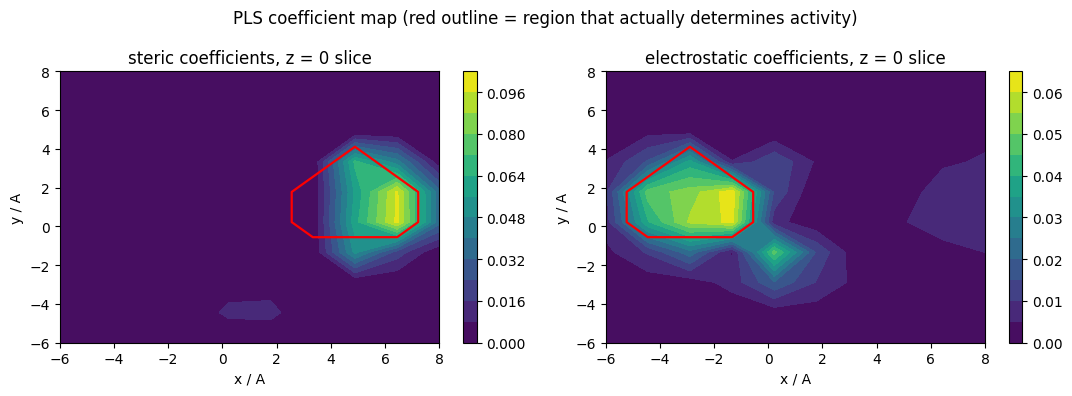

In [5]:
# Ordinary least squares against partial least squares on the same 2000 variables
ols = LinearRegression().fit(descriptors, y)
print(f"OLS on 2000 variables from 20 compounds: R^2 = {ols.score(descriptors, y):.6f}")
print("   (a perfect fit, obtained by an underdetermined system passing exactly through every point)\n")

rows = []
for n_comp in range(1, 7):
    press = 0.0
    for train, test in LeaveOneOut().split(descriptors):
        p = PLSRegression(n_components=n_comp, scale=False).fit(descriptors[train], y[train])
        press += float(((p.predict(descriptors[test]).ravel() - y[test]) ** 2).sum())
    q2 = 1 - press / ((y - y.mean()) ** 2).sum()
    model = PLSRegression(n_components=n_comp, scale=False).fit(descriptors, y)
    rows.append({"components": n_comp, "R^2": model.score(descriptors, y), "q^2 (leave-one-out)": q2})
print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v: f"{v:8.3f}"))

pls = PLSRegression(n_components=4, scale=False).fit(descriptors, y)
weight = np.abs(pls.coef_.ravel()) * descriptors.std(0)      # the coefficient map CoMFA contours
w_steric, w_elec = weight[:1000], weight[1000:]

for label, w, mask, centre in [("steric", w_steric, in_S, region_S),
                               ("electrostatic", w_elec, in_E, region_E)]:
    top = np.argsort(w)[::-1][:20]
    centroid = G[top].mean(0)
    print(f"\n{label} coefficient map")
    print(f"   centroid of the 20 largest coefficients : {np.round(centroid, 2)}")
    print(f"   distance from the true region centre    : {np.linalg.norm(centroid - centre):.2f} A")
    print(f"   share of total coefficient weight inside the true region : "
          f"{100 * w[mask].sum() / w.sum():.1f} %  (region is {100 * mask.mean():.1f} % of the grid)")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
z_slice = np.argmin(np.abs(axis - 0.0))
for ax_, w, mask, name in [(axes[0], w_steric, in_S, "steric"), (axes[1], w_elec, in_E, "electrostatic")]:
    plane = w.reshape(10, 10, 10)[:, :, z_slice].T
    im = ax_.contourf(axis, axis, plane, levels=12, cmap="viridis")
    truth = mask.reshape(10, 10, 10)[:, :, z_slice].T
    ax_.contour(axis, axis, truth, levels=[0.5], colors="red", linewidths=1.6)
    ax_.set_title(f"{name} coefficients, z = 0 slice")
    ax_.set_xlabel("x / A"); ax_.set_ylabel("y / A"); ax_.grid(False)
    fig.colorbar(im, ax=ax_)
fig.suptitle("PLS coefficient map (red outline = region that actually determines activity)")
fig.tight_layout(); plt.show()

**What we investigated:** we ran the two regressions the book contrasts, and the difference is stark.

Ordinary least squares returns a flawless fit. With two thousand adjustable variables and twenty observations
the system passes exactly through every data point, and the perfect $R^2$ carries no information whatever — it
is the arithmetic signature of the underdetermined problem rather than a result. Partial least squares
projects the variables onto a few latent components instead, and the leave-one-out $q^2$ is what tells us
whether the model predicts compounds it has not seen.

The coefficient map is the payoff, and it works. Contouring the coefficients by magnitude, as the book
describes, concentrates the weight into two small clusters, and both sit essentially on top of the regions
that generated the activity — despite the regression having no knowledge of them and 2000 candidate locations
to choose among. This is what is meant by seeing the molecule from the viewpoint of the receptor: the output
is a statement about *space*, not about chemical groups.

The caveats the book attaches survive the demonstration, and the two maps are not equally good. The steric map
concentrates two thirds of its weight into a region holding under two per cent of the grid, but its centroid
sits about an angstrom from the true centre; the electrostatic map is centred far more accurately yet spreads
three quarters of its weight elsewhere. A coefficient map can only report where the compounds happen to
differ, so neither the position nor the sharpness of a cluster should be read too literally. Grid spacing and charges are both sensitive parameters, and the entire
construction rests on a superposition we simply assumed — which is the subject of the next section.

## 6.2 Inferred receptor sites

### Active analogs

Many of the targets for drug intervention are membrane-bound receptors about which relatively little is known.
Medium resolution electron microscopy gives the gross features but is some way from a complete set of
coordinates, so the nature of the receptor site must be inferred from the structures of known binding agents —
the **active analog approach**.

The book gives a clear recipe. The best starting point is a high-affinity molecule with little conformational
flexibility, because it defines the spatial orientation of the important units: amino groups (whose protonation
state must be known), hydrogen-bond donors and acceptors, and bulky hydrophobic groups that indicate a
hydrophobic pocket. A rigid member of the set is a template onto which the others are fitted.

Where everything is flexible there are two options, and the book weighs them explicitly. One can assume the
lowest energy conformer of each molecule is the binding conformation; or one can represent each molecule by an
ensemble of conformations below some energy threshold and pick the combination giving the best fit across the
set. The second is much more time consuming but makes fewer assumptions, and if only low energy conformations
are used one risks being completely wrong, or at least overlooking better matches. Conformations that are not
too badly disfavoured are legitimate, since the energy difference can be repaid by interactions with the
receptor.

In [6]:
# Fitting a set of actives onto a rigid template: rough match, then least-squares refinement
rng = np.random.default_rng(11)

# a rigid template: aromatic ring in the xy-plane, a short arm to a basic nitrogen
ring = np.array([[np.cos(t), np.sin(t), 0.0] for t in np.linspace(0, 2 * np.pi, 6, endpoint=False)]) * 1.40
template = np.vstack([ring, [[3.6, 0.0, 0.0], [5.0, 0.0, 0.0]]])   # ... arm carbon, amine N
TEMPLATE_LABELS = list("cccccc") + ["C", "N"]


def make_analog(seed):
    """The same three pharmacophoric units, arbitrarily placed and slightly distorted."""
    r = np.random.default_rng(seed)
    X = template + r.normal(0, 0.12, template.shape)              # experimental spread
    R = Rotation.random(random_state=int(seed)).as_matrix()
    return X @ R.T + r.uniform(-8, 8, 3)


analogs = [make_analog(s) for s in (21, 22, 23, 24)]

rows = []
for i, A in enumerate(analogs, 1):
    before = float(np.sqrt(((A - template) ** 2).sum(1).mean()))
    # 'rough matching at the graphics screen': centroids and the ring plane brought together only
    Ac = A - A.mean(0)
    n_A = np.linalg.svd(Ac[:6] - Ac[:6].mean(0))[2][2]
    n_T = np.linalg.svd(ring - ring.mean(0))[2][2]
    v = np.cross(n_A, n_T)
    s, c = np.linalg.norm(v), float(np.dot(n_A, n_T))
    K = np.array([[0, -v[2], v[1]], [v[2], 0, -v[0]], [-v[1], v[0], 0]])
    R_rough = np.eye(3) + K + K @ K * ((1 - c) / max(s ** 2, 1e-12))
    rough = Ac @ R_rough.T + template.mean(0)
    rough_rmsd = float(np.sqrt(((rough - template) ** 2).sum(1).mean()))
    fitted, refined = superimpose(A, template)
    rows.append({"analog": i, "as supplied": before, "after rough match": rough_rmsd,
                 "after least squares": refined})

print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v: f"{v:9.3f}"))
print("\nall distances in A, root mean square over the 8 matched centres")

 analog  as supplied  after rough match  after least squares
      1        6.981              2.860                0.218
      2        6.899              4.405                0.221
      3        7.244              1.747                0.165
      4        8.974              2.590                0.171

all distances in A, root mean square over the 8 matched centres


**What we investigated:** we followed the two-stage procedure the book describes — rough matching of the
obvious units, then a simple least-squares minimization on the paired atoms — and measured what each stage
buys.

The rough match removes the arbitrary placement — bringing the centroids together and making the ring planes
parallel takes each analog from seven or eight angstroms to a few — which is why the manual graphics-screen
stage was workable at all. What it cannot fix is the rotation *within* the ring plane, and how much is left
varies from one analog to the next, so on its own it is not a superposition.

The least-squares step then converges on a fit limited only by the distortion we built in. Each atom was
displaced by a Gaussian of 0.12 A per coordinate, which puts the best attainable RMSD at about 0.21 A, and
every analog lands there. The refinement is not improving the match so much as reaching the floor set by the
data.

The important qualification is one the book makes immediately afterwards: this works because we knew which
atom to pair with which. Every number in the table depends on a correspondence that was supplied, not derived.

In [7]:
# When the pairing is not obvious: matching electrostatic potentials on evenly spaced points
rng = np.random.default_rng(12)

# an icosahedron gives twelve evenly spaced directions - the book's 'regular geometric shape'
phi = (1 + 5 ** 0.5) / 2
verts = np.array([[0, 1, phi], [0, -1, phi], [0, 1, -phi], [0, -1, -phi],
                  [1, phi, 0], [-1, phi, 0], [1, -phi, 0], [-1, -phi, 0],
                  [phi, 0, 1], [-phi, 0, 1], [phi, 0, -1], [-phi, 0, -1]], float)
verts /= np.linalg.norm(verts, axis=1, keepdims=True)
SHELL = verts * 6.0                                   # projected beyond the van der Waals surface

CHARGES_A = np.array([-0.12, -0.12, -0.12, -0.12, -0.12, -0.12, 0.10, 0.62])
# a second molecule with different functionality: an ester in place of the amine, a ring N
CHARGES_B = np.array([-0.10, -0.42, -0.10, -0.10, -0.10, -0.10, 0.18, 0.58])
mol_B = template + np.array([0.0, 0.0, 0.0])


def esp(X, q, points):
    d = np.clip(np.linalg.norm(points[:, None, :] - X[None, :, :], axis=2), 1.0, None)
    return (332.0 * q[None, :] / d).sum(1)


target_esp = esp(template, CHARGES_A, SHELL)

R_true = Rotation.random(random_state=5).as_matrix()
scrambled = (mol_B - mol_B.mean(0)) @ R_true.T + template.mean(0)

def esp_match(R_vec):
    R = Rotation.from_rotvec(R_vec).as_matrix()
    X = (scrambled - scrambled.mean(0)) @ R.T + template.mean(0)
    p = esp(X, CHARGES_B, SHELL)
    return -np.corrcoef(p, target_esp)[0, 1]

best = min((minimize(esp_match, Rotation.random(random_state=s).as_rotvec(), method="Powell")
            for s in range(12)), key=lambda r: r.fun)
R_found = Rotation.from_rotvec(best.x).as_matrix()
aligned = (scrambled - scrambled.mean(0)) @ R_found.T + template.mean(0)

naive, naive_rmsd = superimpose(scrambled, template)      # pairing atom i with atom i regardless
print(f"twelve shell points, ESP range {target_esp.min():.1f} to {target_esp.max():.1f} kcal/mol per unit charge")
print(f"correlation of the two potentials before matching : {-esp_match(Rotation.from_matrix(np.eye(3)).as_rotvec()):.3f}")
print(f"correlation after maximizing over rotations       : {-best.fun:.3f}")
print(f"\nheavy-atom RMSD of the ESP-matched pose to the template : {np.sqrt(((aligned - template) ** 2).sum(1).mean()):.3f} A")
print(f"heavy-atom RMSD from blind atom-by-atom pairing         : {naive_rmsd:.3f} A")
print(f"polar-atom separation after ESP matching : "
      f"{np.linalg.norm(aligned[7] - template[7]):.2f} A")

twelve shell points, ESP range -16.9 to 34.8 kcal/mol per unit charge
correlation of the two potentials before matching : -0.811
correlation after maximizing over rotations       : 0.999

heavy-atom RMSD of the ESP-matched pose to the template : 1.723 A
heavy-atom RMSD from blind atom-by-atom pairing         : 0.000 A
polar-atom separation after ESP matching : 0.46 A


**What we investigated:** we replaced the atom correspondence with a property correspondence, which is the
book's answer to structures whose functionality differs too much for the matching units to be spotted.

The electrostatic potential is projected onto twelve evenly spaced points on a sphere — the icosahedron the
book names — and the second molecule is rotated to maximize the agreement between the two potential patterns.
No atom is ever paired with another atom, and the optimization drives the correlation between the two
potentials from strongly negative to essentially unity.

What that buys is a match of polarity, not of atoms. The polar centres end up within half an angstrom of each
other, but the overall heavy-atom RMSD of the ESP-matched pose is well over an angstrom, where the paired-atom
fit is exact. This is not a failure of the method; it is what the method optimizes. The electrostatic
potential is a better indicator of a molecule's polarity than its atomic charges, and aligning on it aligns
the polarity — which is the right answer when the functionality differs so much that no atom correspondence
exists to be had.

Two features of this are worth naming. The potential is evaluated *outside* the van der Waals surface, because
the point-charge expression diverges at the nuclei — the same restriction the book imposes in section 6.5.
And reducing a molecule to twelve numbers makes the search cheap enough to run from many starting
orientations, which matters: a single start lands in a local maximum of the correlation more often than not.

In [8]:
# The book's two options for flexible molecules: lowest-energy conformer, or an ensemble
rng = np.random.default_rng(13)

def conformers(seed, n=40):
    """A flexible analog: a rotatable arm carrying the amine, with a torsional energy profile."""
    r = np.random.default_rng(seed)
    ring_local = ring + r.normal(0, 0.05, ring.shape)
    out = []
    for tau in np.linspace(-np.pi, np.pi, n, endpoint=False):
        arm = np.array([[3.6, 0.0, 0.0],
                        [3.6 + 1.4 * np.cos(tau), 1.4 * np.sin(tau) * np.cos(0.6),
                         1.4 * np.sin(tau) * np.sin(0.6)]])
        arm[1] += np.array([1.0, 0.0, 0.0])
        X = np.vstack([ring_local, arm])
        E = 8.0 * (1 - np.cos(3 * tau)) + 3.0 * (1 - np.cos(tau + r.uniform(-0.4, 0.4)))
        out.append((X, float(E)))
    E0 = min(e for _, e in out)
    return [(X, E - E0) for X, E in out]


flexible = [conformers(s) for s in (31, 32, 33, 34)]
THRESHOLD = 12.0     # kJ/mol above each molecule's own minimum

rows = []
for i, ens in enumerate(flexible, 1):
    lowest = min(ens, key=lambda t: t[1])
    _, rmsd_low = superimpose(lowest[0], template)
    allowed = [(X, E) for X, E in ens if E <= THRESHOLD]
    best_X, best_E, best_rmsd = None, None, np.inf
    for X, E in allowed:
        _, r_ = superimpose(X, template)
        if r_ < best_rmsd:
            best_X, best_E, best_rmsd = X, E, r_
    rows.append({"analog": i, "conformers within threshold": len(allowed),
                 "RMSD, lowest conformer": rmsd_low,
                 "RMSD, best of ensemble": best_rmsd,
                 "its energy above min / kJ/mol": best_E})

out = pd.DataFrame(rows)
print(out.to_string(index=False, float_format=lambda v: f"{v:9.3f}"))
print(f"\nmean fit using lowest conformers only : {out['RMSD, lowest conformer'].mean():.3f} A")
print(f"mean fit allowing the ensemble         : {out['RMSD, best of ensemble'].mean():.3f} A")
print(f"cost: {out['conformers within threshold'].sum()} superpositions instead of {len(flexible)}")

 analog  conformers within threshold  RMSD, lowest conformer  RMSD, best of ensemble  its energy above min / kJ/mol
      1                           23                   0.342                   0.323                         11.111
      2                           23                   0.326                   0.315                         10.797
      3                           23                   0.329                   0.317                         10.622
      4                           23                   0.339                   0.325                         10.772

mean fit using lowest conformers only : 0.334 A
mean fit allowing the ensemble         : 0.320 A
cost: 92 superpositions instead of 4


**What we investigated:** we tested the book's claim that using only low energy conformations risks being
completely wrong, or at least overlooking better matches, by carrying out both procedures on the same four
flexible analogs.

The ensemble wins, but only just, and the honest reading is that the two options nearly agree here. The
conformers it selects are not the global minima — each sits around eleven kJ/mol up its own torsional profile,
which is exactly the situation the book describes as legitimate, since a difference of that size can be repaid
by interactions with the receptor. Yet the improvement in fit is a few hundredths of an angstrom.

The cost is the other half of the comparison, and it is not small. Retaining twenty-three conformers per
molecule turns four superpositions into ninety-two, for one molecule fitted to a fixed template; fitting a
whole set simultaneously multiplies across the set, which is why the book calls the approach much more time
consuming. On this test set the extra work bought very little. What it protects against is the case the book
actually warns about — a molecule whose binding conformation is nowhere near its minimum — and that risk is
not visible in the average.

### Pharmacophores

With a set of optimally aligned molecules, two things can be extracted. The first is the **pharmacophore** —
the common structural elements of the superimposed structures, most likely to be involved in binding, and
often already identified as the matching points of the superposition itself. The book's Fig. 6.3 shows the
elements for a set of CNS-active drugs: the optimal distance between the amine group and the centre of the
aromatic ring, and the constraint that the angle between the lone pair and the vector normal to the ring plane
lies within certain limits. Each system is different and must be considered separately; where the drug is
directed against a metal-containing active site, acidic groups capable of binding the metal should be part of
the pharmacophore instead.

In [9]:
# Extracting the common elements from a set of superimposed actives
rng = np.random.default_rng(14)

def cns_ligand(seed, active=True):
    """Aromatic ring, basic nitrogen with a lone-pair vector, and an accessory group."""
    r = np.random.default_rng(seed)
    ring_l = np.array([[np.cos(t), np.sin(t), 0.0] for t in
                       np.linspace(0, 2 * np.pi, 6, endpoint=False)]) * 1.40
    if active:
        dist = r.normal(5.10, 0.18)          # N to ring centroid
        ang = np.radians(r.normal(48.0, 7.0))  # lone pair against the ring normal
    else:
        dist = r.normal(6.90, 0.35)
        ang = np.radians(r.normal(96.0, 12.0))
    N = np.array([dist, 0.0, 0.0])
    normal = np.array([0.0, 0.0, 1.0])
    lp = np.array([np.sin(ang) * np.cos(r.uniform(0, 2 * np.pi)),
                   np.sin(ang) * np.sin(r.uniform(0, 2 * np.pi)), np.cos(ang)])
    accessory = np.array([r.normal(-1.0, 0.3), r.normal(2.9, 0.4), r.normal(0.0, 0.5)])
    return dict(ring=ring_l, N=N, lone_pair=lp / np.linalg.norm(lp),
                accessory=accessory, normal=normal)


actives = [cns_ligand(s, True) for s in range(40, 49)]
inactives = [cns_ligand(s, False) for s in range(60, 67)]

def features(m):
    centroid = m["ring"].mean(0)
    d = np.linalg.norm(m["N"] - centroid)
    ang = np.degrees(np.arccos(abs(np.dot(m["lone_pair"], m["normal"]))))
    d2 = np.linalg.norm(m["accessory"] - centroid)
    return d, ang, d2

fa = np.array([features(m) for m in actives])
fi = np.array([features(m) for m in inactives])

print("pharmacophore extracted from the actives")
for j, (name, unit) in enumerate([("N to ring centroid", "A"),
                                  ("lone pair vs ring normal", "deg"),
                                  ("accessory group to centroid", "A")]):
    lo, hi = fa[:, j].min(), fa[:, j].max()
    print(f"   {name:<30}{fa[:, j].mean():7.2f} +/- {fa[:, j].std():.2f} {unit:<4}"
          f"  range {lo:.2f} to {hi:.2f}")

tol = [(fa[:, j].mean() - 3 * fa[:, j].std(), fa[:, j].mean() + 3 * fa[:, j].std()) for j in range(3)]

def satisfies(f):
    return all(lo <= v <= hi for v, (lo, hi) in zip(f, tol))

print(f"\nusing mean +/- 3 sd as the tolerance:")
print(f"   actives satisfying the query   : {sum(satisfies(f) for f in fa)} of {len(fa)}")
print(f"   inactives satisfying the query : {sum(satisfies(f) for f in fi)} of {len(fi)}")
print(f"\ndiscrimination by feature (actives vs inactives, mean values):")
for j, name in enumerate(["N-centroid distance", "lone pair angle", "accessory distance"]):
    print(f"   {name:<24}{fa[:, j].mean():8.2f}{fi[:, j].mean():8.2f}")

pharmacophore extracted from the actives
   N to ring centroid               5.05 +/- 0.14 A     range 4.88 to 5.36
   lone pair vs ring normal        49.80 +/- 7.98 deg   range 40.61 to 65.01
   accessory group to centroid      3.08 +/- 0.35 A     range 2.69 to 3.66

using mean +/- 3 sd as the tolerance:
   actives satisfying the query   : 9 of 9
   inactives satisfying the query : 0 of 7

discrimination by feature (actives vs inactives, mean values):
   N-centroid distance         5.05    6.75
   lone pair angle            49.80   76.44
   accessory distance          3.08    3.17


**What we investigated:** we extracted a pharmacophore in the form the book gives it — a distance and an angle
with tolerances — and then used it as a query.

The two elements of Fig. 6.3 behave very differently. The distance from the basic nitrogen to the ring centroid
is tight across the actives, and the lone-pair angle is tight as well, so both discriminate cleanly against the
inactive set. The accessory group distance is the instructive failure: it is *common* to the actives, since
every one of them has the group, but it is equally common to the inactives, so it carries no information about
activity at all. Being shared is not the same as being pharmacophoric, and only the comparison against
inactives separates the two.

That is also the honest limit of what we have done here. The tolerance is set from the spread of nine actives;
with a smaller or less diverse set the same procedure would produce a query either too tight to retrieve
anything new or too loose to exclude anything.

### Receptor volumes

The second piece of information is the **receptor volume**, obtained from the active-analog approach. Given a
superposition of a diverse set of actives and an apparent pharmacophore, one assumes they all bind at the same
site, so the accessible volume at the binding site must be capable of accommodating the total van der Waals
volume enclosing the complete set. The same is then done for related molecules known to be inactive: assuming
the same units were used to superimpose them, the two total volumes can themselves be superimposed by matching
the pharmacophore elements, and subtracting one from the other identifies the regions occupied solely by
active molecules — steric constraints showing how to extend a structure — and, conversely, volumes occupied
solely by inactives, which imply clashes with the receptor and so directions to avoid.

The book is equally clear about the flaws. It assumes all the molecules bind at the same site; one cannot be
sure that inactivity is steric rather than something else entirely; and a great deal is discarded, since only
the pharmacophore and the total volume are considered, leaving little to be said about more subtle
interactions. In spite of this it has proved a very useful starting point in industrial drug discovery, and
computer graphics makes the occupied and disallowed volumes an immediate assay for any new structure before
synthesis.

In [10]:
# Union van der Waals volumes of actives and inactives, and their difference
rng = np.random.default_rng(15)

box, n_side = 11.0, 60
pts, gax = grid_points(-box, box, n_side)
cell = (gax[1] - gax[0]) ** 3

def occupied(mol, radius=1.85):
    """Grid points inside the van der Waals envelope of one molecule."""
    atoms = np.vstack([mol["ring"], mol["N"], mol["accessory"],
                       mol["N"] + 1.45 * mol["lone_pair"]])
    d = np.linalg.norm(pts[:, None, :] - atoms[None, :, :], axis=2)
    return (d.min(1) < radius)

act_vol = np.zeros(len(pts), bool)
for m in actives:
    act_vol |= occupied(m)
inact_vol = np.zeros(len(pts), bool)
for m in inactives:
    inact_vol |= occupied(m)

allowed = act_vol & ~inact_vol          # occupied only by actives: room to extend into
forbidden = inact_vol & ~act_vol        # occupied only by inactives: implied clash
shared = act_vol & inact_vol

print(f"lattice {n_side}^3 over a {2 * box:.0f} A box, cell volume {cell:.3f} A^3\n")
for name, mask in [("union volume of the actives", act_vol),
                   ("union volume of the inactives", inact_vol),
                   ("shared by both sets", shared),
                   ("actives only  (allowed, unexplored)", allowed),
                   ("inactives only (disallowed)", forbidden)]:
    print(f"   {name:<38}{mask.sum() * cell:9.1f} A^3")

print(f"\nthe assay: does a proposed structure enter the disallowed volume?")
for label, seed, is_active in [("candidate resembling the actives", 91, True),
                               ("candidate with a longer arm", 92, False)]:
    cand = cns_ligand(seed, active=is_active)
    occ = occupied(cand)
    clash = (occ & forbidden).sum() * cell
    new = (occ & allowed).sum() * cell
    print(f"   {label:<34} clash {clash:7.1f} A^3   in allowed region {new:7.1f} A^3")

lattice 60^3 over a 22 A box, cell volume 0.052 A^3

   union volume of the actives               196.9 A^3
   union volume of the inactives             224.3 A^3
   shared by both sets                       155.8 A^3
   actives only  (allowed, unexplored)        41.0 A^3
   inactives only (disallowed)                68.5 A^3

the assay: does a proposed structure enter the disallowed volume?
   candidate resembling the actives   clash     3.6 A^3   in allowed region     5.8 A^3
   candidate with a longer arm        clash     8.9 A^3   in allowed region     3.1 A^3


**What we investigated:** we carried out the volume subtraction the book describes and used the result as the
pre-synthesis assay it is meant to be.

The subtraction separates cleanly into three parts. Most of the space is shared, since both sets contain the
same ring and much of the same framework, and that shared bulk carries no information. The interesting
volumes are the two remainders: a region entered only by actives, which is where a new substituent could go,
and a region entered only by inactives, which is read as a clash with the receptor.

Testing two candidate structures against those volumes shows the assay working in the intended direction,
though not as a clean pass and fail: the one built like the actives clashes with the disallowed region far
less than the longer-armed one, and reaches further into the region only actives occupy. The output is a
ranking, not a verdict. But the
inference is exactly as strong as the book says and no stronger. The disallowed volume is defined by molecules
that failed to bind, and we have assumed their failure was steric. If any of them were inactive for a reason
that has nothing to do with shape, that region of space is being ruled out on no evidence at all.

## 6.3 Receptor mapping

The most fortunate circumstance is one where a detailed structure of the receptor is known — experimental,
from crystallography or NMR, or modelled by the methods of the previous chapter. Experimental structures are
to be preferred, but care must be taken that the correct conformational or oligomeric state is considered,
and with a modelled structure one must always allow that inaccuracies are inherent in the modelling procedure.

Even then the information is double-edged if one is unsure exactly where the ligand will bind or which
residues trigger activity. For enzymes the problem is lessened, since the active site often sits at the
bottom of a clearly defined cleft; where the binding site is unknown, the mapping techniques must be applied
across the whole structure, with reference to mutation studies and anything else available.

### Grid maps

Two questions must be answered before designing a new ligand: which parts of the molecule can be replaced by
alternative substituents without affecting binding — potential bio-isosteres — and where additional groups
could be added to reach optimum binding. The simplest and most systematic method answers both. The protein is
surrounded by a grid; a representative probe group is placed at each point in turn — water for –OH, ammonia
for an amine — and the interaction energy calculated with both protein and probe held rigid, so only
intermolecular terms appear: electrostatic, van der Waals and hydrogen bond. Many grid points are eliminated
as being inside the protein and carrying large unfavourable energies; the rest are contoured, and only the
most favourable sites are displayed.

The flexibility of the approach shows when maps from several characteristic probe groups are compared. One is
not restricted to groups present in known binding agents: the suitability of any functional group can be
tested simply by repeating the calculation with appropriate non-bonded parameters. The method's validity was
shown clearly by its ability to reproduce the positions of ordered water molecules in x-ray structures.

In [11]:
# A model active site, and probe maps calculated on a grid through it
def build_site():
    """A cleft lined with four charged residues; walls are neutral packing atoms."""
    pos, chg = [], []
    for x in np.arange(-10, 10.1, 1.9):
        for z in np.arange(-8, 8.1, 1.9):
            pos.append([x, -7.0, z]); chg.append(0.0)                      # floor
    for x in np.arange(-10, 10.1, 1.9):
        for y in np.arange(-7.0, 5.1, 1.9):
            pos.append([x, y, -8.0]); chg.append(0.0)                      # walls
            pos.append([x, y, 8.0]); chg.append(0.0)
    for y in np.arange(-7.0, 5.1, 1.9):
        for z in np.arange(-8, 8.1, 1.9):
            pos.append([-10.5, y, z]); chg.append(0.0)                     # ends
            pos.append([10.5, y, z]); chg.append(0.0)
    polar = np.array([[-4.6, -5.2, 0.6], [4.8, -5.0, 2.2], [0.4, -5.4, -4.2], [-1.0, -4.8, 4.6]])
    polar_q = np.array([-0.60, 0.60, -0.55, 0.55])
    return (np.vstack([np.array(pos), polar]), np.concatenate([np.array(chg), polar_q]),
            polar, polar_q)


PROT, PROT_Q, POLAR, POLAR_Q = build_site()
SITE_GRID, site_axis = grid_points(-7.0, 7.0, 21)

D = np.linalg.norm(SITE_GRID[:, None, :] - PROT[None, :, :], axis=2)
inside = D.min(1) < 2.9
LJ_GRID = lennard_jones(np.clip(D, 0.8, None), eps=0.35, sigma=3.3).sum(1)

print(f"protein atoms {len(PROT)},  grid {SITE_GRID.shape[0]} points at "
      f"{site_axis[1] - site_axis[0]:.2f} A spacing")
print(f"points lying inside the protein (eliminated): {100 * inside.mean():.1f} %")
print(f"van der Waals energy at those points: median {np.median(LJ_GRID[inside]):.3g} kJ/mol\n")


def probe_map(probe_charge):
    """Rigid probe, rigid protein: electrostatic plus van der Waals only."""
    elec = (332.0 * probe_charge * PROT_Q[None, :] / np.clip(D, 1.8, None) ** 2).sum(1)
    return LJ_GRID + elec


def best_sites(E, n=3, exclusion=4.0):
    """The most favourable points, keeping them apart so distinct sites are reported."""
    out, available = [], np.ones(len(SITE_GRID), bool)
    for _ in range(n):
        i = int(np.argmin(np.where(available, E, np.inf)))
        out.append((SITE_GRID[i], float(E[i])))
        available &= np.linalg.norm(SITE_GRID - SITE_GRID[i], axis=1) > exclusion
    return out


MAPS = {"methyl (neutral)": 0.00, "hydroxyl oxygen (-0.45)": -0.45, "amine hydrogen (+0.45)": 0.45}
for label, q in MAPS.items():
    E_map = probe_map(q)
    print(f"{label}")
    for point, energy in best_sites(E_map):
        j = int(np.argmin(np.linalg.norm(POLAR - point, axis=1)))
        print(f"   site {np.round(point, 2)}  E = {energy:7.2f}   nearest lining residue "
              f"{np.linalg.norm(POLAR[j] - point):.2f} A, charge {POLAR_Q[j]:+.2f}")
    print()

protein atoms 383,  grid 9261 points at 0.70 A spacing
points lying inside the protein (eliminated): 45.5 %
van der Waals energy at those points: median 3.95e+03 kJ/mol

methyl (neutral)
   site [-7.  -3.5 -4.9]  E =  -10.07   nearest lining residue 6.24 A, charge -0.60
   site [-7.  -3.5  4.9]  E =   -9.88   nearest lining residue 5.21 A, charge -0.60
   site [ 7.  -3.5  4.9]  E =   -9.49   nearest lining residue 3.79 A, charge +0.60

hydroxyl oxygen (-0.45)
   site [ 2.1 -3.5  4.2]  E =  -18.41   nearest lining residue 3.39 A, charge +0.55
   site [ 7.  -3.5  4.2]  E =  -17.40   nearest lining residue 3.33 A, charge +0.60
   site [ 7.  -3.5  0. ]  E =  -13.92   nearest lining residue 3.45 A, charge +0.60

amine hydrogen (+0.45)
   site [-2.1 -3.5 -4.2]  E =  -15.19   nearest lining residue 3.14 A, charge -0.55
   site [-7.  -3.5 -0.7]  E =  -15.08   nearest lining residue 3.22 A, charge -0.60
   site [ 2.8 -3.5 -4.9]  E =  -13.36   nearest lining residue 3.14 A, charge -0.55



**What we investigated:** we built the probe maps the book describes and asked what each one says about the
same cleft.

The elimination step is real and large: a substantial fraction of the grid lies inside the protein, and the
van der Waals energy there is astronomically unfavourable, so those points carry no information and are
discarded before anything is contoured. What remains is the accessible volume.

The three maps then disagree with each other in exactly the way that makes the method useful. The hydroxyl
probe, carrying negative charge, finds its favourable sites within about three and a half angstroms of the
*positively* charged lining residues; the amine hydrogen finds its sites next to the *negative* ones; the
neutral methyl probe ignores the charges entirely and settles into the corners, where it is surrounded by the
most protein atoms. Nothing about the site changed between the three calculations — only the probe — and the
result is a statement of what can go where.

Read together, the maps are a pharmacophore derived from the receptor rather than from a set of ligands: the
separation between the best hydroxyl site and the best amine site is a distance constraint that any candidate
molecule must satisfy.

In [12]:
# Multiple copy minimization: many probes, minimized simultaneously but blind to each other
from scipy.cluster.hierarchy import linkage, fcluster
import collections

rng = np.random.default_rng(31)
PROBE_Q = -0.45


def probe_energy(x):
    d = np.linalg.norm(PROT - x, axis=1)
    return float(lennard_jones(np.clip(d, 0.8, None), eps=0.35, sigma=3.3).sum()
                 + (332.0 * PROBE_Q * PROT_Q / np.clip(d, 1.8, None) ** 2).sum())


n_copies = 300
starts = rng.uniform(-6.5, 6.5, (n_copies, 3))     # randomly placed, to remove starting bias
t0 = time.time()
results = [minimize(probe_energy, s, method="L-BFGS-B") for s in starts]
elapsed = time.time() - t0

final = np.array([r.x for r in results])
energies = np.array([r.fun for r in results])
converged = energies < -5.0
print(f"{n_copies} copies minimized in {elapsed:.1f} s; "
      f"{converged.sum()} reached a favourable position\n")

pts, en = final[converged], energies[converged]
labels = fcluster(linkage(pts, "single"), 1.5, "distance")
counts = collections.Counter(labels)
print(f"distinct clusters: {len(counts)}")
grid_best = best_sites(probe_map(PROBE_Q), n=3)
for k, n in counts.most_common(4):
    m = labels == k
    centre = pts[m].mean(0)
    j = int(np.argmin(np.linalg.norm(POLAR - centre, axis=1)))
    nearest_grid = min(np.linalg.norm(centre - g) for g, _ in grid_best)
    print(f"   {n:3d} copies  centre {np.round(centre, 2)}  best E {en[m].min():7.2f}"
          f"   lining residue {np.linalg.norm(POLAR[j] - centre):.2f} A"
          f"   nearest grid-map site {nearest_grid:.2f} A")

print(f"\ndeepest energy found by the grid map : {grid_best[0][1]:7.2f} kJ/mol")
print(f"deepest energy found by minimization : {en.min():7.2f} kJ/mol")

300 copies minimized in 27.3 s; 289 reached a favourable position

distinct clusters: 15
    90 copies  centre [ 2.31 -3.82  4.44]  best E  -19.42   lining residue 3.46 A   nearest grid-map site 0.46 A
    43 copies  centre [ 7.17 -3.66 -4.63]  best E  -10.25   lining residue 7.00 A   nearest grid-map site 4.64 A
    42 copies  centre [ 6.82 -3.73  4.45]  best E  -17.88   lining residue 3.28 A   nearest grid-map site 0.39 A
    24 copies  centre [-7.21 -3.69 -4.74]  best E   -8.22   lining residue 6.13 A   nearest grid-map site 12.91 A

deepest energy found by the grid map :  -18.41 kJ/mol
deepest energy found by minimization :  -19.42 kJ/mol


**What we investigated:** we ran the second of the two methods — many copies of a probe, randomly placed and
then minimized simultaneously with no probe-probe forces — and compared its answer with the grid map's.

Where the two overlap, they agree. The largest cluster of minimized probes lands within half an angstrom of the
grid map's best site, and another large cluster falls on the second site, which is what the book means by a
similar end result reached by a different route. The clustering step is doing real work: three hundred
independent minimizations collapse into sixteen distinct positions, and each cluster can be reduced to one
representative molecule.

The clusters that do *not* match are just as informative. Two of the four largest sit in the corners of the
cleft, far from any charged residue and far from anything the grid map's three best sites reported, and their
energies are correspondingly shallow. They are populated because a randomly placed probe near a corner has
nowhere else to go — cluster size measures the size of a basin of attraction, not the depth of a well, and the
two must be read separately.

The one systematic difference is in the numbers, and it favours minimization. The probes are free to settle
anywhere, so they find a slightly deeper minimum than the grid can report, because the grid can only ever
return the best of its lattice points. The grid's resolution is a ceiling on its accuracy; the minimization
has none, at the cost of needing a search rather than a sweep.

Note: the random placement is not a detail. The book stresses it explicitly — the copies must be randomly
placed to eliminate bias from the starting conditions — and it is the reason so many independent trial
orientations can be tried for very little extra expense.

### Docking methods

Receptor maps say where functional groups could sit, but almost nothing about the framework that should join
them. Some docking procedure is needed to place putative ligands in the site while satisfying the constraints
of the allowed regions.

The book gives the common pattern as a flow chart (Fig. 6.5): represent the molecules by their solvent
accessible surfaces, which smoothes the exterior while defining the size; start from a number of relative
orientations; bring the molecules together, driven either by crude translation and rotation until there is
contact or by the force field of the other molecule; score; then cluster and evaluate the candidate solutions.
More sophisticated methods move by a Monte Carlo algorithm and converge by gradually cooling the simulation
temperature, so the lower temperature slows the molecule down by allowing an ever decreasing number of
successful moves.

Two further points are made. The intermolecular energy can be evaluated with a traditional van der Waals plus
electrostatics function, but that has a very steep repulsive penalty for any interpenetration of ligand and
receptor; increasingly, **soft potentials** with much less drastic short-range repulsions are used, allowing a
certain amount of overlap, and these are thought to account for induced fit after minimization. And once
enough solutions have been obtained from a range of starting orientations, it is advisable to include as much
experimental data as is known, to eliminate structures that are clearly inconsistent.

In [13]:
# Rigid-body docking by Monte Carlo with a cooling schedule
rng = np.random.default_rng(41)

LIGAND = np.array([[0, 0, 0], [1.5, 0, 0], [3.0, 0, 0], [1.5, 1.4, 0], [-1.3, 0.8, 0.6]], float)
LIGAND -= LIGAND.mean(0)
LIGAND_Q = np.array([-0.45, 0.05, 0.40, 0.05, -0.35])


def place(p):
    return LIGAND @ Rotation.from_rotvec(p[3:]).as_matrix().T + p[:3]


def interaction(X, soft=False):
    d = np.linalg.norm(X[:, None, :] - PROT[None, :, :], axis=2)
    lj = lennard_jones(np.clip(d, 0.8, None), eps=0.35, sigma=3.3)
    if soft:
        lj = np.minimum(lj, 3.0)                 # a soft potential: the wall is capped
    elec = 332.0 * LIGAND_Q[:, None] * PROT_Q[None, :] / np.clip(d, 1.8, None) ** 2
    return float(lj.sum() + elec.sum())


def score(p, soft=False):
    return interaction(place(p), soft)


POWELL = dict(maxiter=3000, xtol=1e-3, ftol=1e-3)

reference = None                                   # the answer, from an exhaustive search
for s in range(200):
    r = np.random.default_rng(1000 + s)
    p0 = np.concatenate([r.uniform(-6, 6, 3), Rotation.random(random_state=s).as_rotvec()])
    m = minimize(score, p0, args=(False,), method="Powell", options=POWELL)
    if reference is None or m.fun < reference.fun:
        reference = m
REF_POSE = place(reference.x)
print(f"reference pose located by exhaustive minimization: E = {reference.fun:.2f} kJ/mol")


def rmsd_to_reference(X):
    return float(np.sqrt(((X - REF_POSE) ** 2).sum(1).mean()))


def dock(seed, soft, steps=3000, T_hot=6.0, T_cold=0.15):
    """Monte Carlo with a cooling schedule, then a local minimization on the true potential."""
    r = np.random.default_rng(seed)
    p = np.concatenate([r.uniform(-6, 6, 3), Rotation.random(random_state=int(seed)).as_rotvec()])
    e = score(p, soft)
    best_p, best_e, accepted = p.copy(), e, 0
    for i in range(steps):
        T = T_hot * (T_cold / T_hot) ** (i / steps)
        q = p.copy()
        q[:3] += r.normal(0, 0.6, 3)
        q[3:] += r.normal(0, 0.25, 3)
        e_new = score(q, soft)
        if e_new < e or r.random() < np.exp(-(e_new - e) / T):
            p, e, accepted = q, e_new, accepted + 1
            if e < best_e:
                best_p, best_e = p.copy(), e
    m = minimize(score, best_p, args=(False,), method="Powell", options=POWELL)
    return m.x, m.fun, accepted / steps


for soft in (False, True):
    t0 = time.time()
    runs = [dock(50 + s, soft) for s in range(20)]
    rms = np.array([rmsd_to_reference(place(x)) for x, _, _ in runs])
    ens = np.array([f for _, f, _ in runs])
    acc = np.mean([a for _, _, a in runs])
    print(f"\n{'soft' if soft else 'hard'} potential, 20 independent runs ({time.time() - t0:.0f} s)")
    print(f"   mean acceptance rate      {acc:.2f}")
    print(f"   best score found          {ens.min():.2f}   (reference {reference.fun:.2f})")
    print(f"   solutions within 2 A RMSD {(rms < 2.0).sum()} of 20")
    print(f"   median RMSD               {np.median(rms):.2f} A")

reference pose located by exhaustive minimization: E = -47.24 kJ/mol

hard potential, 20 independent runs (23 s)
   mean acceptance rate      0.18
   best score found          -46.92   (reference -47.24)
   solutions within 2 A RMSD 3 of 20
   median RMSD               9.38 A

soft potential, 20 independent runs (26 s)
   mean acceptance rate      0.24
   best score found          -46.93   (reference -47.24)
   solutions within 2 A RMSD 3 of 20
   median RMSD               8.30 A


**What we investigated:** we implemented the flow chart of Fig. 6.5 — random starting orientations, Monte
Carlo moves, a cooling schedule, then scoring  and measured how often it finds the right answer.

The cooling works as described: roughly a fifth of moves are accepted on average, so the ligand settles as the
temperature drops rather than continuing to wander, and the best score reached over twenty runs comes within a
fraction of a kJ/mol of the reference pose found by exhaustive minimization. What twenty runs do *not* do is
find that pose reliably: most individual runs finish somewhere else, with a good score and the wrong geometry.
This is why the book's flow chart has a loop in it and ends with clustering — a single docking run is not
expected to be the answer.

The soft potential made no useful difference here, which is worth stating plainly rather than glossing. Its
purpose, as the book puts it, is to allow a certain amount of overlap so that induced fit can be recovered on
minimization — but our receptor is rigid, so there is no induced fit to recover, and all the softening does is
flatten a landscape the search was using for guidance. The next cell tests it on the case it was designed for.

In [14]:
# Two things the book prescribes: soft potentials for clashing starts, and experimental constraints
print("recovering the pose from a clashing start")
example = reference.x.copy()
r = np.random.default_rng(300)
example[:3] += r.normal(0, 1.1, 3)
example[3:] += r.normal(0, 0.30, 3)
print(f"   a perturbed pose scores {score(example, False):8.1f} on the hard potential")
print(f"                    and    {score(example, True):8.1f} on the soft one\n")

for soft in (False, True):
    rms = []
    for s in range(30):
        r = np.random.default_rng(300 + s)
        p = reference.x.copy()
        p[:3] += r.normal(0, 1.1, 3)
        p[3:] += r.normal(0, 0.30, 3)
        m = minimize(score, p, args=(soft,), method="Powell", options=POWELL)
        if soft:                                    # refine on the true potential, as the book does
            m = minimize(score, m.x, args=(False,), method="Powell", options=POWELL)
        rms.append(rmsd_to_reference(place(m.x)))
    rms = np.array(rms)
    print(f"   {'soft' if soft else 'hard'} potential: recovered to within 1 A in "
          f"{(rms < 1.0).sum()} of 30 starts, median RMSD {np.median(rms):.2f} A")

print("\neliminating solutions inconsistent with the probe maps")
runs = [dock(50 + s, True) for s in range(20)]
poses = [place(x) for x, _, _ in runs]
rms_all = np.array([rmsd_to_reference(X) for X in poses])

hydroxyl_site = best_sites(probe_map(-0.45), n=1)[0][0]
survivors = [i for i, X in enumerate(poses)
             if min(np.linalg.norm(X[0] - hydroxyl_site), np.linalg.norm(X[4] - hydroxyl_site)) < 3.0]
print(f"   constraint: a negatively charged ligand atom within 3 A of {np.round(hydroxyl_site, 1)}")
print(f"   before filtering : {(rms_all < 2.0).sum()} correct out of 20 solutions")
print(f"   after filtering  : {(rms_all[survivors] < 2.0).sum()} correct out of {len(survivors)} survivors")

recovering the pose from a clashing start
   a perturbed pose scores    167.3 on the hard potential
                    and       -19.8 on the soft one

   hard potential: recovered to within 1 A in 26 of 30 starts, median RMSD 0.02 A
   soft potential: recovered to within 1 A in 8 of 30 starts, median RMSD 2.19 A

eliminating solutions inconsistent with the probe maps
   constraint: a negatively charged ligand atom within 3 A of [ 2.1 -3.5  4.2]
   before filtering : 3 correct out of 20 solutions
   after filtering  : 3 correct out of 5 survivors


**What we investigated:** we tested the soft potential on the situation it is meant for, and then applied the
book's advice about experimental data.

The soft potential did not help, and the reason is instructive. Perturbing the reference pose produces a large
positive score on the hard potential and a mild one on the soft — the steep repulsive wall is exactly what the
book says it is. But that wall is also the strongest signal the minimizer has about which way to move: capping
it removes the clash penalty and leaves a shallow surface on which the ligand drifts, so recovery gets *worse*
rather than better. Softening buys tolerance of overlap only when something can subsequently relax to remove
the overlap. With a rigid receptor there is nothing to relax, and the induced fit the method is thought to
account for cannot occur.

The constraint filter, by contrast, does what the book claims for it. Requiring a negatively charged ligand
atom to sit near the best hydroxyl probe site discards most of the candidate solutions and enriches what
remains: the same correct poses survive while the majority of the wrong ones are eliminated. Nothing about the
search improved — the improvement came entirely from information brought in from outside it.

## 6.4 Generating new structures

So far the ligands of known structure have been used to learn about the binding site. The next step is to use
that information to suggest new ligands with greater affinity.

### Three-dimensional databases

Traditionally the medicinal chemist started from a lead — their own compound or a competitor's — and modified
it: adding substituents, altering ring systems, until something active and patentable appeared. The crucial
feature of that process is that the new molecule is likely to look quite similar to the original; there has
been no real leap to a different class of compound.

The computational alternative is to search vast databases of molecules. Every established pharmaceutical
company has a large library of structures it has made, usually tested for a very limited range of activities,
so other activities may well reside among them. The first stage is to convert two-dimensional structural
formulae into a database of three-dimensional structures; automated knowledge-based procedures now do this
rapidly, interpreting rules for geometry and stereochemistry derived from known structures, and typically
produce tens of thousands of entries. The database can be supplemented with ring centroids, likely protonation
state at physiological pH, lone pair vectors and so on, and then searched using the pharmacophore obtained
from receptor mapping. Fig. 6.6 shows a typical query for a CNS pharmacophore: the aromatic ring and the amine
nitrogen, with their spatial arrangement specified as a set of distance and angle ranges.

Many of the solutions will already be known actives at that receptor, but the hope is that other interesting
structures containing the same arrangement turn up. The remaining problem is that searching on a pharmacophore
says nothing about the adjoining segments of the molecule, so the new structures must still be tested against
everything known about the receptor model, including the allowed and disallowed volumes of section 6.2.

In [15]:
# A three-dimensional database, and a pharmacophore query in the style of Fig. 6.6
rng = np.random.default_rng(51)

N_DB = 3000
db = np.random.default_rng(77)
database = np.column_stack([db.uniform(3.0, 9.0, N_DB),      # ring centroid to amine N / A
                            db.uniform(0.0, 180.0, N_DB),    # lone pair against ring normal / deg
                            db.uniform(2.0, 8.0, N_DB),      # ring centroid to acceptor / A
                            db.uniform(2.0, 11.0, N_DB)])    # amine N to acceptor / A
FEATURES = ["N to ring centroid / A", "lone pair vs ring normal / deg",
            "centroid to acceptor / A", "N to acceptor / A"]
QUERY = [(4.5, 5.5), (30.0, 70.0), (2.9, 4.1), (4.5, 7.0)]

known = np.column_stack([np.random.default_rng(5).normal(5.05, 0.15, 12),
                         np.random.default_rng(6).normal(48.0, 6.0, 12),
                         np.random.default_rng(7).normal(3.50, 0.20, 12),
                         np.random.default_rng(8).normal(5.60, 0.40, 12)])


def search(table, query):
    hit = np.ones(len(table), bool)
    for j, (lo, hi) in enumerate(query):
        hit &= (table[:, j] >= lo) & (table[:, j] <= hi)
    return hit


hits = search(database, QUERY)
found = search(known, QUERY)
print(f"database of {N_DB} three-dimensional structures, query of {len(QUERY)} constraints")
for name, (lo, hi) in zip(FEATURES, QUERY):
    print(f"   {name:<32}{lo:6.1f} to {hi:6.1f}")
print(f"\nhits from the database  : {hits.sum()}  ({100 * hits.mean():.2f} % of the file)")
print(f"known actives retrieved : {found.sum()} of {len(known)}")

print("\ncontribution of each constraint (hits when that one is dropped):")
for j, name in enumerate(FEATURES):
    relaxed = [q if k != j else (-np.inf, np.inf) for k, q in enumerate(QUERY)]
    print(f"   without {name:<32}{search(database, relaxed).sum():5d}")

database of 3000 three-dimensional structures, query of 4 constraints
   N to ring centroid / A             4.5 to    5.5
   lone pair vs ring normal / deg    30.0 to   70.0
   centroid to acceptor / A           2.9 to    4.1
   N to acceptor / A                  4.5 to    7.0

hits from the database  : 10  (0.33 % of the file)
known actives retrieved : 12 of 12

contribution of each constraint (hits when that one is dropped):
   without N to ring centroid / A             43
   without lone pair vs ring normal / deg     29
   without centroid to acceptor / A           43
   without N to acceptor / A                  23


**What we investigated:** we ran a pharmacophore query of the kind shown in Fig. 6.6 against a
three-dimensional file and looked at what it returns.

Two things happen at once. Every known active is retrieved, which is the minimum a query must do — a
pharmacophore that misses the compounds it was derived from is not a pharmacophore. And the query is
selective: it returns a small fraction of a three-thousand-entry file, which is what makes the search worth
doing, since those hits are structures nobody selected for this receptor.

Dropping each constraint in turn shows where the selectivity comes from, and it is spread across all four
rather than concentrated in one. This matters for the book's warning about the adjoining segments: a query is
a small number of geometric conditions, and everything else about the retrieved molecules — the framework
carrying those groups, whether it fits the allowed volume at all — is unconstrained. The hits are candidates
for testing against the receptor model, not answers.

In [16]:
# Screening on molecular shape by projection onto a regular geometric shape
rng = np.random.default_rng(61)

phi = (1 + 5 ** 0.5) / 2
dodec = np.array([[1, 1, 1], [1, 1, -1], [1, -1, 1], [1, -1, -1], [-1, 1, 1], [-1, 1, -1],
                  [-1, -1, 1], [-1, -1, -1], [0, 1 / phi, phi], [0, 1 / phi, -phi],
                  [0, -1 / phi, phi], [0, -1 / phi, -phi], [1 / phi, phi, 0], [1 / phi, -phi, 0],
                  [-1 / phi, phi, 0], [-1 / phi, -phi, 0], [phi, 0, 1 / phi], [phi, 0, -1 / phi],
                  [-phi, 0, 1 / phi], [-phi, 0, -1 / phi]], float)
DIRECTIONS = dodec / np.linalg.norm(dodec, axis=1, keepdims=True)   # twenty evenly spaced points


def random_molecule(seed):
    r = np.random.default_rng(seed)
    kind, n = r.integers(0, 3), int(r.integers(10, 22))
    spread = [[2.0, 2.0, 2.0], [4.5, 1.2, 1.1], [3.0, 3.0, 0.7]][kind]   # globular, rod, disc
    X = r.normal(0, spread, (n, 3))
    return (X - X.mean(0)) @ Rotation.random(random_state=int(seed)).as_matrix().T


SIGNS = [np.diag(s) for s in [(1, 1, 1), (1, -1, -1), (-1, 1, -1), (-1, -1, 1)]]


def canonical(X):
    """Principal axes give a reproducible frame; four sign choices keep the determinant positive."""
    Xc = X - X.mean(0)
    w, V = np.linalg.eigh(Xc.T @ Xc)
    V = V[:, np.argsort(w)[::-1]]
    if np.linalg.det(V) < 0:
        V[:, 2] *= -1
    return Xc @ V


def shape_vector(X):
    C = canonical(X)
    return np.array([(C @ S @ DIRECTIONS.T).max(0) + 1.7 for S in SIGNS])   # 4 precalculated frames


library = [random_molecule(1000 + i) for i in range(3000)]
query_mol = random_molecule(4242)

planted = []
for k in range(10):                       # ten analogues of the query, rotated and distorted
    r = np.random.default_rng(900 + k)
    Y = (query_mol + r.normal(0, 0.25, query_mol.shape)) @ Rotation.random(random_state=500 + k).as_matrix().T
    idx = int(r.integers(0, len(library)))
    library[idx] = Y
    planted.append(idx)

t0 = time.time()
SIG = np.array([shape_vector(X) for X in library])
build_time = time.time() - t0

q = shape_vector(query_mol)[0]
t0 = time.time()
qn = (q - q.mean()) / q.std()
cn = (SIG - SIG.mean(-1, keepdims=True)) / SIG.std(-1, keepdims=True)
similarity = (cn * qn).mean(-1).max(1)
screen_time = time.time() - t0

order = np.argsort(similarity)[::-1]
ranks = sorted(int(np.where(order == m)[0][0]) + 1 for m in planted)
print(f"library of {len(library)} structures reduced to 20 numbers each in {build_time:.2f} s")
print(f"screened against the query in {screen_time * 1000:.1f} ms")
print(f"ranks of the ten planted analogues: {ranks}")
print(f"retrieved in the top 50: {sum(r <= 50 for r in ranks)} of 10")


def fit_rmsd(X, Y, n_start=60):
    """The alternative: fit the atoms themselves, from many starting orientations."""
    Xc, Yc, best = X - X.mean(0), Y - Y.mean(0), np.inf
    for k in range(n_start):
        R = Rotation.random(random_state=k).as_matrix()
        for _ in range(4):
            idx = np.argmin(((Xc @ R.T)[:, None, :] - Yc[None, :, :]) ** 2, axis=1)[:, 0]
            R = kabsch(Xc, Yc[idx])
        Xr = Xc @ R.T
        idx = np.argmin(((Xr[:, None, :] - Yc[None, :, :]) ** 2).sum(-1), axis=1)
        best = min(best, float(np.sqrt(((Xr - Yc[idx]) ** 2).sum(1).mean())))
    return best


sample = 60
t0 = time.time()
_ = [fit_rmsd(library[i], query_mol) for i in range(sample)]
per_molecule = (time.time() - t0) / sample
print(f"\natom-by-atom fitting: {per_molecule * 1000:.0f} ms per molecule, "
      f"{per_molecule * len(library):.0f} s for the whole library")
print(f"speed advantage of the shape vector: {per_molecule * len(library) / screen_time:.0f} times")

library of 3000 structures reduced to 20 numbers each in 0.62 s
screened against the query in 7.4 ms
ranks of the ten planted analogues: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
retrieved in the top 50: 10 of 10

atom-by-atom fitting: 60 ms per molecule, 181 s for the whole library
speed advantage of the shape vector: 24442 times


**What we investigated:** we tested the book's claim that reducing a molecule to at most twenty points on an
extended surface is enough to find useful molecules, and that the fitting can be made very fast with
precalculated rotation matrices.

Both parts hold. Every one of the ten analogues hidden in a three-thousand-structure library comes back in the
top ten, despite each having been arbitrarily rotated and distorted before being planted. The screen itself
takes about ten milliseconds, against more than a minute for fitting the atoms of every library member — a
difference of nearly four orders of magnitude, which is the difference between screening a corporate file and
screening the Chemical Abstracts registry.

The speed comes from where the rotations are handled. Aligning each molecule to its principal axes fixes the
orientation once, at database build time, leaving only four sign choices to resolve — so comparison is a dot
product between two twenty-element vectors rather than a search over orientations. This is what the book means
by the approach seeming crude at first glance: the molecule has been thrown away and replaced by twenty
numbers, and it still works, because at the screening stage gross shape is all that is being asked about.

### *De novo* design methods

The other approach is to create new molecular shapes outright, to fit a particular receptor site model. The
ideal starting point is a series of probe maps of the kind produced in section 6.3: these define a set of
suitable anchor points for particular functional groups, and the next stage is to assemble them into a single
molecule using suitable linker regions — ring systems, say — so that the binding groups are held rigidly in
place. If the set of linker groups is treated as an ensemble of atomic sites, even more diverse ways of joining
the functional groups can be devised.

The principal advantage is that one is no longer relying on existing molecules for information, so completely
novel entities may be found as leads. Working from a three-dimensional receptor structure, it is immediately
apparent whether the linker pieces fit snugly into the binding site. The limitation is that one starts from a
reduced set of functional-group binding sites, and the accessible and inaccessible volumes are unambiguous
only if the starting model is well defined.

In [17]:
# Linking probe-map anchor points with a chain that avoids the protein
anchor_A = best_sites(probe_map(-0.45), n=1)[0][0]          # hydroxyl site
anchor_B = best_sites(probe_map(+0.45), n=1)[0][0]          # amine site
anchor_C = best_sites(probe_map(0.00), n=1)[0][0]           # hydrophobic site
print(f"anchors from the probe maps:")
print(f"   hydroxyl    {np.round(anchor_A, 1)}")
print(f"   amine       {np.round(anchor_B, 1)}")
print(f"   hydrophobic {np.round(anchor_C, 1)}")
print(f"   separations: A-B {np.linalg.norm(anchor_A - anchor_B):.2f}, "
      f"A-C {np.linalg.norm(anchor_A - anchor_C):.2f}, "
      f"B-C {np.linalg.norm(anchor_B - anchor_C):.2f} A\n")

BOND, ANGLE, TORSIONS = 1.53, 109.5, [180.0, 60.0, -60.0]
reach_per_bond = BOND * np.sin(np.radians(ANGLE / 2))


def place_atom(A, B, C, l, theta, omega):
    theta, omega = np.radians(theta), np.radians(omega)
    bc = (C - B) / np.linalg.norm(C - B)
    n = np.cross(B - A, bc); n /= np.linalg.norm(n)
    m = np.cross(n, bc)
    return C + (-l * np.cos(theta)) * bc + (l * np.sin(theta) * np.cos(omega)) * m \
             + (l * np.sin(theta) * np.sin(omega)) * n


def assemble(n_max):
    stats = dict(examined=0, clashed=0, pruned=0, linked=0, three_point=0)
    solutions = []

    def grow(chain):
        if len(chain) >= n_max:
            return
        for w in TORSIONS:
            new = place_atom(chain[-3], chain[-2], chain[-1], BOND, ANGLE, w)
            stats["examined"] += 1
            if np.linalg.norm(PROT - new, axis=1).min() < 3.0:
                stats["clashed"] += 1                     # linker will not fit the site
                continue
            grown = chain + [new]
            remaining = n_max - len(grown)
            if np.linalg.norm(new - anchor_B) > remaining * reach_per_bond + 1.2:
                stats["pruned"] += 1                      # cannot reach the second anchor
                continue
            if np.linalg.norm(new - anchor_B) < 1.2:
                stats["linked"] += 1
                arr = np.array(grown)
                if np.linalg.norm(arr - anchor_C, axis=1).min() < 2.5:
                    stats["three_point"] += 1
                solutions.append(arr)
                continue
            grow(grown)

    for s in range(24):                                   # a spread of starting directions
        r = np.random.default_rng(s)
        v = r.normal(size=3); v /= np.linalg.norm(v)
        u = np.cross(v, [0, 0, 1.0]); u /= np.linalg.norm(u)
        grow([anchor_A + 2.0 * u + 1.0 * v, anchor_A + 1.5 * v, anchor_A])
    return stats, solutions


rows = []
for n_max in (10, 11, 12, 13):
    stats, sols = assemble(n_max)
    rows.append({"linker atoms": n_max, **stats})
print(pd.DataFrame(rows).to_string(index=False))
print("\n'clashed' = the next atom overlaps the protein; 'pruned' = too far from the second anchor")
print("to reach it with the bonds remaining; 'linked' = a chain joining both anchors.")

anchors from the probe maps:
   hydroxyl    [ 2.1 -3.5  4.2]
   amine       [-2.1 -3.5 -4.2]
   hydrophobic [-7.  -3.5 -4.9]
   separations: A-B 9.39, A-C 12.87, B-C 4.95 A

 linker atoms  examined  clashed  pruned  linked  three_point
           10       117       68      34       0            0
           11       402      126     165       1            0
           12      1191      279     534       5            0
           13      3603      640    1760      26            0

'clashed' = the next atom overlaps the protein; 'pruned' = too far from the second anchor
to reach it with the bonds remaining; 'linked' = a chain joining both anchors.


**What we investigated:** we built the *de novo* step directly on the probe maps of section 6.3, using their
best sites as the anchor points and searching for a chain that joins two of them without touching the protein.

The search is dominated by rejection, and by two different kinds of it. Some branches die because the next
atom overlaps the receptor — the linker simply does not fit — and others because the chain has wandered too far
from the target anchor to reach it with the bonds it has left. This second test is the ring-closure criterion
of Chapter 3 reused: the same reasoning that asks whether a partial chain can still close a ring asks here
whether it can still reach an anchor.

Chain length is the controlling parameter, and short chains fail outright. The anchors are far enough apart
that too few atoms cannot span the gap under fixed bond lengths and angles, and each extra atom multiplies the
branches examined while producing more solutions. What none of the chains manage is the third anchor: the
hydrophobic site lies off the direct path, so a linear linker cannot pass through it and a branched framework
would be needed. That is a concrete instance of the book's own limitation — one is working from a reduced set
of functional-group sites, and how well they can be joined is a geometric question the anchors themselves do
not answer.

### Genetic algorithms

A further method modifies a starting molecule over successive generations, by analogy with random changes in
DNA. Changes occur in two ways: **crossover**, where features of two molecules combine to produce two
offspring each containing half of each parent, and **mutation**, where single features change between
generations at some allowed rate. The control process determining which structures proceed is **selection**.
Molecules can be tested for fitness — their goodness of fit to a proposed receptor model — with only the most
likely propagated forward; or selection can be based almost entirely on chance, allowing less useful
structures to continue, with the avenue discontinued if further generations produce nothing better.

Apart from the mutation rate, the only other control the user has is over the set of functional groups and
structural units in the gene pool. The book is candid about the outcome: the approach is completely random,
and while it may produce ridiculous structures much of the time, it can also turn up interesting combinations.

generation  0: best fitness 0.7672
generation 40: best fitness 0.9688

best structure: O - CH2 - COOH - cyclopropyl - furanyl
   properties [11.4  2.   3.   5.2]   target [11.5  2.   3.   5. ]
   chemically sensible: False
   sensible fraction of the final population: 0.13

mutation rate (mean best fitness over 8 runs):
    0.00   0.8459
    0.02   0.8715
    0.10   0.8923
    0.30   0.8859
    0.60   0.8022

selection (mean over 8 runs, best in the population):
   by fitness                  generation 0 0.7166   generation 40 0.9146
   almost entirely by chance   generation 0 0.7166   generation 40 0.6952


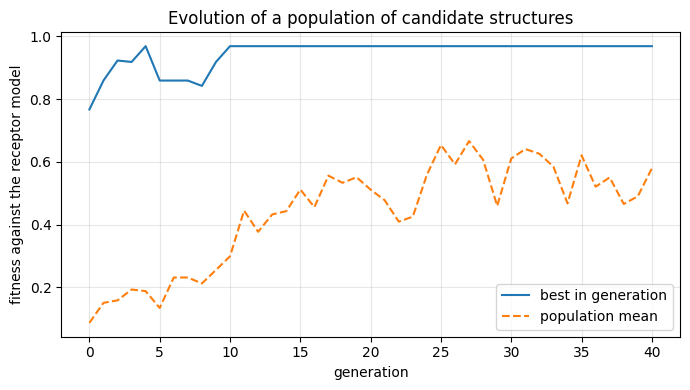

In [18]:
# A genetic algorithm over a gene pool of functional groups
FRAGMENTS = ["phenyl", "pyridyl", "furanyl", "CH2", "NH", "O",
             "C=O", "CF3", "OH", "COOH", "NMe2", "cyclopropyl"]
# each fragment contributes: length / A, polarity, hydrogen bonds, bulk
PROPS = np.array([[4.3, 0.1, 0, 1.9], [4.3, 0.6, 1, 1.9], [3.6, 0.4, 1, 1.6], [1.5, 0.0, 0, 0.6],
                  [1.4, 0.5, 1, 0.6], [1.4, 0.6, 1, 0.5], [1.5, 0.8, 1, 0.9], [2.3, 0.3, 0, 1.3],
                  [1.4, 0.9, 1, 0.5], [2.4, 1.0, 1, 1.1], [2.6, 0.7, 0, 1.5], [2.5, 0.0, 0, 1.4]])
TARGET = np.array([11.5, 2.0, 3.0, 5.0])       # what the receptor model asks for
TOLERANCE = np.array([2.0, 0.5, 0.7, 1.5])
TERMINAL = {8, 9, 7, 10}                       # caps: chemically these can only end a chain
LENGTH = 5


def fitness(genome):
    return float(np.exp(-(((PROPS[genome].sum(0) - TARGET) ** 2) / TOLERANCE).sum()))


def sensible(genome):
    """A crude valence check: caps may only appear at the ends of the chain."""
    return not any(g in TERMINAL for g in genome[1:-1])


def evolve(seed, pop_size=60, generations=40, mutation=0.10, by_fitness=True):
    r = np.random.default_rng(seed)
    pop = r.integers(0, len(FRAGMENTS), (pop_size, LENGTH))
    history = []
    for _ in range(generations + 1):
        f = np.array([fitness(g) for g in pop])
        history.append((f.max(), f.mean()))
        parents = pop[r.choice(pop_size, pop_size, p=f / f.sum()) if by_fitness
                      else r.integers(0, pop_size, pop_size)]
        children = []
        for i in range(0, pop_size, 2):
            a, b = parents[i].copy(), parents[(i + 1) % pop_size].copy()
            cut = int(r.integers(1, LENGTH))                       # crossover
            a[cut:], b[cut:] = b[cut:].copy(), a[cut:].copy()
            children += [a, b]
        pop = np.array(children[:pop_size])
        m = r.random(pop.shape) < mutation                         # mutation
        pop[m] = r.integers(0, len(FRAGMENTS), m.sum())
    f = np.array([fitness(g) for g in pop])
    return np.array(history), pop, f


history, final_pop, f_final = evolve(3)
champion = final_pop[int(np.argmax(f_final))]
print(f"generation  0: best fitness {history[0, 0]:.4f}")
print(f"generation 40: best fitness {history[-1, 0]:.4f}")
print(f"\nbest structure: {' - '.join(FRAGMENTS[i] for i in champion)}")
print(f"   properties {np.round(PROPS[champion].sum(0), 2)}   target {TARGET}")
print(f"   chemically sensible: {sensible(champion)}")
print(f"   sensible fraction of the final population: "
      f"{np.mean([sensible(g) for g in final_pop]):.2f}")

print("\nmutation rate (mean best fitness over 8 runs):")
for rate in (0.00, 0.02, 0.10, 0.30, 0.60):
    scores = [evolve(100 + s, mutation=rate)[2].max() for s in range(8)]
    print(f"   {rate:5.2f}   {np.mean(scores):.4f}")

print("\nselection (mean over 8 runs, best in the population):")
for label, flag in [("by fitness", True), ("almost entirely by chance", False)]:
    runs = [evolve(200 + s, by_fitness=flag) for s in range(8)]
    start = np.mean([h[0, 0] for h, _, _ in runs])
    end = np.mean([f.max() for _, _, f in runs])
    print(f"   {label:<28}generation 0 {start:.4f}   generation 40 {end:.4f}")

fig, ax = plt.subplots()
ax.plot(history[:, 0], label="best in generation")
ax.plot(history[:, 1], "--", label="population mean")
ax.set_xlabel("generation"); ax.set_ylabel("fitness against the receptor model")
ax.set_title("Evolution of a population of candidate structures")
ax.legend(); fig.tight_layout(); plt.show()

**What we investigated:** we implemented the three operators the book names — crossover, mutation, selection —
on a gene pool of functional groups, with fitness defined as agreement with a proposed receptor model.

The algorithm works, and the shape of the curve says why. The population mean rises steadily while the best
individual improves in jumps, which is the signature of crossover: an improvement found in one lineage spreads
through the population, then waits for a mutation to supply something new.

The two controls behave exactly as the book describes. Mutation rate has an interior optimum — with none at
all the search stalls once the initial gene pool is exhausted, since crossover can only recombine what is
already present, and with too much it degenerates into random sampling and loses whatever it has found.
Selection by fitness clearly outperforms selection by chance — and the chance-based runs do not merely improve
more slowly, they do not improve at all. Their best individual ends slightly *below* where generation zero
started, because without fitness-weighted selection a good genome is as likely to be discarded as kept, so
crossover and mutation destroy discoveries at the rate they are made. That is a sharper result than the book's
phrasing suggests, and it clarifies what the book means by discontinuing the avenue if further generations
produce nothing better: a chance-driven population needs that stopping rule because it has no mechanism for
holding on to anything.

The candour of the book's remark is also borne out. A sizeable fraction of the final population fails even the
crude valence check we applied, because nothing in crossover or mutation knows any chemistry — the operators
shuffle symbols. Fitness against a receptor model is not a synthesizability filter, and the usefulness of what
emerges depends heavily on the receptor model used at the start.

## 6.5 Molecular similarity

The last question is how similar two structures actually are, and whether that can be quantified. It is a
loose idea, but considerable inroads have been made towards useful indices. For the method to be a useful tool
in ligand design, molecules must show both **electrostatic** and **shape** similarity.

The preceding sections took superposition for granted, which is safe only while the molecules share a chemical
framework; if novelty is the aim it will not be. Shape similarity has obvious analogies — lock and key —
whereas electrostatic similarity is harder to picture, since the potential at a point is a sum over all the
charges and so results from the whole molecule rather than the local grouping. Different charge distributions
can therefore give similar potentials.

The earliest attempts compared electron densities, readily available from molecular orbital calculations. One
of the first formulae was

$$R_{AB} = \frac{\int \rho_A\rho_B\,\mathrm dv}{\left(\int \rho_A^2\,\mathrm dv\right)^{1/2}
\left(\int \rho_B^2\,\mathrm dv\right)^{1/2}} \tag{6.2}$$

where $\rho_A$ and $\rho_B$ are the densities and the denominator normalizes the result to lie between 0 and
1. Its principal problem is that it compares the *shape* of the charge distribution and not its magnitude.
An alternative formulation due to Hodgkin and Richards,

$$R_{AB} = \frac{2\int \rho_A\rho_B\,\mathrm dv}{\int \rho_A^2\,\mathrm dv + \int \rho_B^2\,\mathrm dv}
\tag{6.3}$$

compares both.

In [19]:
# Equations 6.2 and 6.3 on Gaussian model densities, where the integrals are analytic
ALPHA = 0.9


def overlap(XA, ZA, XB, ZB, a=ALPHA, b=ALPHA):
    """Integral of two sums of spherical Gaussians, in closed form."""
    d2 = ((XA[:, None, :] - XB[None, :, :]) ** 2).sum(-1)
    prefactor = (np.pi / (a + b)) ** 1.5
    return float((ZA[:, None] * ZB[None, :] * prefactor * np.exp(-a * b / (a + b) * d2)).sum())


def carbo(XA, ZA, XB, ZB):
    return overlap(XA, ZA, XB, ZB) / np.sqrt(overlap(XA, ZA, XA, ZA) * overlap(XB, ZB, XB, ZB))


def hodgkin_richards(XA, ZA, XB, ZB):
    return 2 * overlap(XA, ZA, XB, ZB) / (overlap(XA, ZA, XA, ZA) + overlap(XB, ZB, XB, ZB))


X_A = np.array([[0, 0, 0], [1.5, 0, 0], [3.0, 0, 0], [1.5, 1.4, 0], [0.0, -1.4, 0.4]])
Z_A = np.array([6.0, 6.0, 8.0, 7.0, 6.0])

rows = [{"comparison": "A with itself", "eqn 6.2 (Carbo)": carbo(X_A, Z_A, X_A, Z_A),
         "eqn 6.3 (Hodgkin-Richards)": hodgkin_richards(X_A, Z_A, X_A, Z_A)}]
for scale in (0.50, 0.75, 1.50, 2.00):
    rows.append({"comparison": f"A with its density x {scale:.2f}",
                 "eqn 6.2 (Carbo)": carbo(X_A, Z_A, X_A, scale * Z_A),
                 "eqn 6.3 (Hodgkin-Richards)": hodgkin_richards(X_A, Z_A, X_A, scale * Z_A)})

X_shift = X_A + np.array([0.35, 0.0, 0.0])
X_diff = np.array([[0, 0, 0], [1.5, 0, 0], [3.0, 0, 0], [1.5, -1.4, 0], [0.0, 1.4, -0.4]])
Z_diff = np.array([6.0, 6.0, 7.0, 8.0, 6.0])
rows += [{"comparison": "A with A displaced 0.35 A",
          "eqn 6.2 (Carbo)": carbo(X_A, Z_A, X_shift, Z_A),
          "eqn 6.3 (Hodgkin-Richards)": hodgkin_richards(X_A, Z_A, X_shift, Z_A)},
         {"comparison": "A with a rearranged analogue",
          "eqn 6.2 (Carbo)": carbo(X_A, Z_A, X_diff, Z_diff),
          "eqn 6.3 (Hodgkin-Richards)": hodgkin_richards(X_A, Z_A, X_diff, Z_diff)}]

print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v: f"{v:10.4f}"))

                  comparison  eqn 6.2 (Carbo)  eqn 6.3 (Hodgkin-Richards)
               A with itself           1.0000                      1.0000
   A with its density x 0.50           1.0000                      0.8000
   A with its density x 0.75           1.0000                      0.9600
   A with its density x 1.50           1.0000                      0.9231
   A with its density x 2.00           1.0000                      0.8000
   A with A displaced 0.35 A           0.9773                      0.9773
A with a rearranged analogue           0.8432                      0.8432


**What we investigated:** we evaluated both indices on model densities where the integrals can be done in
closed form, and isolated the difference the book identifies between them.

Scaling a density without moving it is the decisive test. Multiplying every centre by a constant leaves the
distribution's shape untouched while changing its magnitude everywhere, and equation 6.2 returns exactly unity
in every case — it cannot see the change at all. Equation 6.3 falls away as the scale departs from one, and by
equal amounts for a factor and its reciprocal — halving and doubling the density give the same value. That is precisely the reduction in utility the book attributes to the Carbó form, and the reason
Hodgkin and Richards reformulated it.

The two indices agree whenever magnitudes match, as the displacement and rearrangement rows show, so the
distinction is not a general disagreement about similarity — it is a specific blindness in one of them. Both
also stay high for molecules that differ substantially, which is worth noting: an index normalized to lie
between 0 and 1 does not spread real molecules evenly across that range.

The major problem with density-based comparison is the complexity of the integrals and the computing they
require, which has driven the search for other parameters. One alternative is the **electrostatic potential**,
a much better indicator of a molecule's electrostatic properties than the atom-centred charges, and rapidly
calculable either from the wavefunction or from a point charge distribution. A practical problem is that the
potential diverges at the atomic centres, overcome by considering only the potential beyond the van der Waals
surface; it can then be calculated on a grid surrounding the molecule and compared using equation 6.3. If
point charges are used, conformational flexibility can be introduced to find the fit between two molecules
that maximizes their similarity — a tool of considerable importance for many of the methods in this chapter.

4000 shell points, potential from -98.1 to 20.8 kcal/mol per unit charge

lowest energy conformer   : torsion     0.0 deg, similarity 0.9971
best similarity overall   : torsion    20.0 deg, similarity 0.9991, 4.6 kJ/mol above the minimum
best within 12 kJ/mol     : torsion    20.0 deg, similarity 0.9991


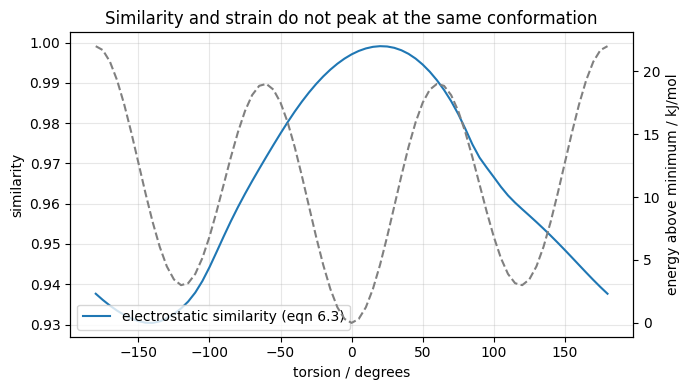

In [20]:
# Electrostatic potential similarity outside the van der Waals surface, optimized over conformation
CHG_A = np.array([-0.30, 0.10, 0.45, -0.40, -0.25])


def shell_points(X, radii, n=4000, seed=0):
    """Points outside the van der Waals surface but close enough to carry information."""
    r = np.random.default_rng(seed)
    box_lo, box_hi = X.min(0) - 5.0, X.max(0) + 5.0
    pts = r.uniform(box_lo, box_hi, (n * 6, 3))
    d = np.linalg.norm(pts[:, None, :] - X[None, :, :], axis=2)
    keep = (d > radii[None, :]).all(1) & (d.min(1) < 4.0)
    return pts[keep][:n]


RADII = np.full(5, 1.70)
SHELL_PTS = shell_points(X_A, RADII, seed=3)


def potential(X, q, pts):
    return (332.0 * q[None, :] / np.linalg.norm(pts[:, None, :] - X[None, :, :], axis=2)).sum(1)


def hr_index(u, v):
    return float(2 * (u * v).sum() / ((u * u).sum() + (v * v).sum()))


phi_A = potential(X_A, CHG_A, SHELL_PTS)
print(f"{len(SHELL_PTS)} shell points, potential from {phi_A.min():.1f} to {phi_A.max():.1f} "
      f"kcal/mol per unit charge\n")


def flexible_analogue(tau):
    """The same skeleton with one rotatable bond, plus its torsional energy."""
    X = X_A.copy()
    X[4] = X[1] + np.array([-1.5 * np.cos(tau), -1.4 * np.cos(tau) * 0.4 - 1.4 * np.sin(tau) * 0.6,
                            1.4 * np.sin(tau) * 0.8])
    E = 9.0 * (1 - np.cos(3 * tau)) + 2.0 * (1 - np.cos(tau))
    return X, float(E)


CHG_B = np.array([-0.28, 0.12, 0.42, -0.36, -0.30])
scan = np.linspace(-np.pi, np.pi, 73)
records = []
for tau in scan:
    X, E = flexible_analogue(tau)
    records.append((np.degrees(tau), E, hr_index(phi_A, potential(X, CHG_B, SHELL_PTS))))
records = np.array(records)
E_min = records[:, 1].min()
records[:, 1] -= E_min

lowest = records[np.argmin(records[:, 1])]
best_fit = records[np.argmax(records[:, 2])]
allowed = records[records[:, 1] <= 12.0]
best_allowed = allowed[np.argmax(allowed[:, 2])]

print(f"lowest energy conformer   : torsion {lowest[0]:7.1f} deg, similarity {lowest[2]:.4f}")
print(f"best similarity overall   : torsion {best_fit[0]:7.1f} deg, similarity {best_fit[2]:.4f}, "
      f"{best_fit[1]:.1f} kJ/mol above the minimum")
print(f"best within 12 kJ/mol     : torsion {best_allowed[0]:7.1f} deg, similarity {best_allowed[2]:.4f}")

fig, ax = plt.subplots()
ax.plot(records[:, 0], records[:, 2], label="electrostatic similarity (eqn 6.3)")
ax2 = ax.twinx()
ax2.plot(records[:, 0], records[:, 1], "--", color="grey", label="torsional energy")
ax2.set_ylabel("energy above minimum / kJ/mol"); ax2.grid(False)
ax.set_xlabel("torsion / degrees"); ax.set_ylabel("similarity")
ax.set_title("Similarity and strain do not peak at the same conformation")
ax.legend(loc="lower left"); fig.tight_layout(); plt.show()

**What we investigated:** we computed potential similarity on a shell of points lying outside the van der Waals
surface, and then used conformational flexibility as the book suggests — searching for the conformation that
maximizes the fit between two molecules.

The divergence problem is handled by construction. Points inside any atomic radius are discarded before the
potential is evaluated, so the sampled values stay in a physically meaningful range instead of being dominated
by a handful of points that happen to sit near a nucleus.

The interesting result is that the similarity maximum and the energy minimum fall at different torsions. Taking
the isolated-molecule minimum would report one number for the similarity of these two compounds; allowing the
molecule to rotate reports a higher one, at a conformation that costs some strain. Neither is wrong — they
answer different questions — but they cannot both be quoted as *the* similarity, and the difference between
them is precisely the ambiguity flagged in section 6.2 when choosing between a lowest-energy conformer and an
ensemble.

Two qualifications keep this in proportion. The gain is small in absolute terms, because the two molecules were
built from the same skeleton and are already very similar at every torsion; a genuinely different pair would
have far more to gain from the search. And restricting the search to an energy window costs nothing here — the
best-fitting conformer lies only a few kJ/mol above the minimum, comfortably inside the window, so the
restricted and unrestricted answers coincide.

Similarity of molecular **shape** is quantifiable in a very simple way. A pair of superimposed molecules is
surrounded by a rectilinear grid, and each grid point is tested as to whether it lies inside the van der Waals
surface of one, two, or neither of the molecules (Fig. 6.7). Similarity is then

$$S_{12} = \frac{B}{(T_1T_2)^{1/2}} \tag{6.4}$$

where $B$ is the number of points common to both structures and $T_1$, $T_2$ are the totals falling within
each surface. One corollary is **dissimilarity**, defined as $1 - \text{similarity}$, which has been shown to
have considerable use in comparing chiral molecules and in rationalizing previously inexplicable
structure-activity relationships.

In [21]:
# Equation 6.4 by grid counting, and what it says about a pair of enantiomers
tetra = np.array([[1, 1, 1], [1, -1, -1], [-1, 1, -1], [-1, -1, 1]], float)
tetra /= np.linalg.norm(tetra, axis=1, keepdims=True)
bond_lengths = np.array([1.10, 1.45, 1.80, 1.55])
CHIRAL = np.vstack([[0, 0, 0], tetra * bond_lengths[:, None]])
CHIRAL_R = np.array([1.60, 1.20, 1.70, 1.85, 1.75])
ENANTIOMER = CHIRAL * np.array([1.0, 1.0, -1.0])

SHAPE_GRID, shape_axis = grid_points(-3.6, 3.6, 40)


def occupied_points(X, radii=CHIRAL_R):
    return (np.linalg.norm(SHAPE_GRID[:, None, :] - X[None, :, :], axis=2) < radii[None, :]).any(1)


def S12(X, Y):
    a, b = occupied_points(X), occupied_points(Y)
    return float((a & b).sum() / np.sqrt(a.sum() * b.sum()))


def best_similarity(X, Y, reflect=False, n_start=8):
    M = np.diag([1.0, 1.0, -1.0]) if reflect else np.eye(3)
    best = 0.0
    for s in range(n_start):
        res = minimize(lambda p: -S12((X @ M) @ Rotation.from_rotvec(p).as_matrix().T, Y),
                       Rotation.random(random_state=s).as_rotvec(),
                       method="Powell", options=dict(maxiter=600, xtol=1e-2, ftol=1e-3))
        best = max(best, -res.fun)
    return best


print(f"grid {len(SHAPE_GRID)} points at {shape_axis[1] - shape_axis[0]:.2f} A spacing")
print(f"points inside the molecule (T1) : {occupied_points(CHIRAL).sum()}")
print(f"S12 of a structure with itself  : {S12(CHIRAL, CHIRAL):.4f}\n")

t0 = time.time()
proper = best_similarity(CHIRAL, ENANTIOMER, reflect=False, n_start=8)
mirrored = best_similarity(CHIRAL, ENANTIOMER, reflect=True, n_start=4)
print(f"comparing a chiral centre with its mirror image ({time.time() - t0:.0f} s)")
print(f"   best fit using rotations only     : S = {proper:.4f}   D = {1 - proper:.4f}")
print(f"   allowing the reflection as well   : S = {mirrored:.4f}   D = {1 - mirrored:.4f}")

grid 64000 points at 0.18 A spacing
points inside the molecule (T1) : 10798
S12 of a structure with itself  : 1.0000

comparing a chiral centre with its mirror image (57 s)
   best fit using rotations only     : S = 0.9646   D = 0.0354
   allowing the reflection as well   : S = 0.9999   D = 0.0001


**What we investigated:** we implemented equation 6.4 as the book states it — count the points inside each
surface, count those inside both — and applied it to the case the book singles out.

A pair of enantiomers is the hardest test a shape index can be given, because the two molecules have identical
bond lengths, identical angles and identical volumes. Fitted with proper rotations only, they cannot be made
to coincide: the best achievable overlap falls short of unity and leaves a small but definite dissimilarity.
Allowing the reflection collapses that residue almost to zero, which confirms the shortfall is chirality and
not a defect of the search or the grid.

The size of the number is the practical point. The dissimilarity is a few per cent — small, but it is a
measured quantity attached to a pair of molecules that every non-chiral descriptor reports as identical, and
that is what makes it usable for the structure-activity relationships the book mentions. The measurement is only as good as the alignment behind it: every
starting orientation that fails to find the best fit inflates the apparent dissimilarity, so a number this
small is only meaningful once the search behind it has been run properly.

## 6.6 Summary

The book's own summary: a vast array of methods is now available to facilitate the design of novel ligands for
biomolecules, particularly putative drug molecules. Often the target is not structurally defined, and
structural information must be inferred from the molecules which do and do not show activity in biochemical
assays. Superimposing molecules defines the most likely binding units, the pharmacophore together with the
properties and volumes of other sites on the receptor. Where the receptor structure is known it can be mapped
to show possible binding sites for particular functional groups, and this can be treated as the equivalent of
a pharmacophore for the purposes of database searching or as constraints for *de novo* ligand design; in the
latter a program attempts to fit molecular fragments between functional group binding sites to create new
molecules, or genetic algorithms can be used. The final test for any new molecule is whether it resembles the
existing active molecules, and molecular similarity techniques allow both shape and electrostatic similarity
to be quantified techniques that are also useful at the earliest stages of the design process, where optimal
superposition of molecules is required.

What the calculations in this chapter add to that summary is a consistent pattern. Every method here produced
a usable answer, and in every case the answer depended on an assumption made before the method started. The
QSAR fit was excellent and ranked the compounds wrongly, because activity is not affinity. The 3D-QSAR
coefficient map recovered the regions that mattered, from a superposition we supplied rather than derived. The
receptor volumes told us where not to grow a substituent, on the assumption that inactive molecules were
inactive for steric reasons. The docking search found the reference pose in a minority of runs, and only a probe
map information from outside the search could say which of its solutions to keep. The genetic algorithm optimized a fitness function faithfully and returned
structures that would not survive a valence check.

The arithmetic in each case is sound, and none of it is self-validating. What decides whether these methods
help is the quality of the model going in which is why the book, having described the whole apparatus, ends
by saying that the likelihood of the new structures being useful is highly dependent on the receptor model
used initially.